In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D         
from matplotlib.patches import Patch
import matplotlib
import subprocess
import os
import sys
import scipy.stats as stats
import scipy
from collections import Counter
import seaborn as sns
# import packages

from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
# turn off a warning from pandas that is not strictly necessary

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(scipy.__version__)
print(sns.__version__)
# print packages versions

plt.rcParams["font.sans-serif"]='Arial'

1.26.4
2.2.2
3.9.2
1.13.1
0.13.2


In [3]:
screen_clin_counts = pd.read_csv('./sgRNAs_annot_wcounts_clin_isolates.csv', sep=',', index_col=0)
# import count dataframe 

In [4]:
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,ERB_T0_YPD_ATC_3,ERB_T3_YPD_ATC_1,ERB_T3_YPD_ATC_2,ERB_T3_YPD_ATC_3,ERB_T3_YPD_ATC_FLU_1,ERB_T3_YPD_ATC_FLU_2,ERB_T3_YPD_ATC_FLU_3,ERB_T3_YPD_ATC_CASP_1,ERB_T3_YPD_ATC_CASP_2,ERB_T3_YPD_ATC_CASP_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,182,210.0,263.0,266.0,58.0,50.0,56.0,229.0,247.0,248.0
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,772,885.0,1256.0,1104.0,464.0,337.0,326.0,1056.0,1090.0,1302.0
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,58,70.0,71.0,61.0,67.0,20.0,20.0,199.0,73.0,101.0
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,136,111.0,124.0,134.0,27.0,40.0,37.0,127.0,111.0,143.0
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,286,291.0,384.0,342.0,293.0,169.0,90.0,340.0,266.0,439.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,2832,3510.0,4189.0,4348.0,1349.0,1177.0,1141.0,3843.0,3726.0,4472.0
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,282,272.0,508.0,426.0,60.0,169.0,75.0,512.0,322.0,659.0
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,1293,1939.0,2430.0,2674.0,737.0,691.0,502.0,2823.0,2293.0,3536.0
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,526,894.0,1070.0,1162.0,519.0,1432.0,427.0,1343.0,1012.0,1366.0


In [5]:
raw_count_col = ['WT_T0_YPD_1', 'WT_T0_YPD_2', 'WT_T0_YPD_3', 'WT_T3_YPD_1', 'WT_T3_YPD_2', 'WT_T3_YPD_3', 'WT_T3_YPD_CASP_1', 'WT_T3_YPD_CASP_2', 'WT_T3_YPD_CASP_3', 'WT_T0_YPD_ATC_1', 'WT_T0_YPD_ATC_2', 'WT_T0_YPD_ATC_3', 'WT_T3_YPD_ATC_1', 'WT_T3_YPD_ATC_2', 'WT_T3_YPD_ATC_3', 'WT_T3_YPD_ATC_CASP_1', 'WT_T3_YPD_ATC_CASP_2', 'WT_T3_YPD_ATC_CASP_3', 'ARB_T0_YPD_1', 'ARB_T0_YPD_2', 'ARB_T0_YPD_3', 'ARB_T3_YPD_1', 'ARB_T3_YPD_2', 'ARB_T3_YPD_3', 'ARB_T3_YPD_CASP_1', 'ARB_T3_YPD_CASP_2', 'ARB_T3_YPD_CASP_3', 'ARB_T0_YPD_ATC_1', 'ARB_T0_YPD_ATC_2', 'ARB_T0_YPD_ATC_3', 'ARB_T3_YPD_ATC_1', 'ARB_T3_YPD_ATC_2', 'ARB_T3_YPD_ATC_3', 'ARB_T3_YPD_ATC_CASP_1', 'ARB_T3_YPD_ATC_CASP_2', 'ARB_T3_YPD_ATC_CASP_3', 'ERB_T0_YPD_1', 'ERB_T0_YPD_2', 'ERB_T0_YPD_3', 'ERB_T3_YPD_1', 'ERB_T3_YPD_2', 'ERB_T3_YPD_3', 'ERB_T3_YPD_CASP_1', 'ERB_T3_YPD_CASP_2', 'ERB_T3_YPD_CASP_3', 'ERB_T0_YPD_ATC_1', 'ERB_T0_YPD_ATC_2', 'ERB_T0_YPD_ATC_3', 'ERB_T3_YPD_ATC_1', 'ERB_T3_YPD_ATC_2', 'ERB_T3_YPD_ATC_3', 'ERB_T3_YPD_ATC_CASP_1', 'ERB_T3_YPD_ATC_CASP_2', 'ERB_T3_YPD_ATC_CASP_3']
# list of columns with raw count data. It can be generated programmatically instead of just copy-pasting

In [6]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

WT_T0_YPD_1 5 36.0 73
WT_T0_YPD_2 2 41.0 63
WT_T0_YPD_3 5 31.700000000000003 75
WT_T0_YPD_ATC_1 4 35.800000000000004 77
WT_T0_YPD_ATC_2 8 40.400000000000006 72
WT_T0_YPD_ATC_3 10 33.2 84
ARB_T0_YPD_1 2 124.0 27
ARB_T0_YPD_2 2 125.0 25
ARB_T0_YPD_3 1 85.1 35
ARB_T0_YPD_ATC_1 0 122.4 25
ARB_T0_YPD_ATC_2 0 97.0 31
ARB_T0_YPD_ATC_3 0 138.2 23
ERB_T0_YPD_1 1 92.1 29
ERB_T0_YPD_2 0 120.2 27
ERB_T0_YPD_3 1 105.0 32
ERB_T0_YPD_ATC_1 2 43.0 63
ERB_T0_YPD_ATC_2 1 121.10000000000002 27
ERB_T0_YPD_ATC_3 0 69.4 40


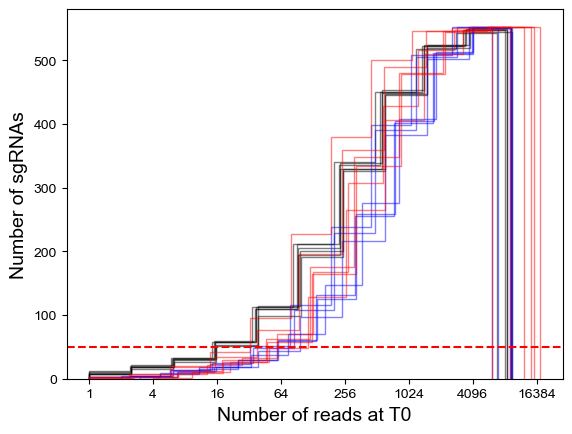

In [7]:
for col in raw_count_col: 
    # loop through raw count columns
    if 'T0' in col:
        # only select T0 samples
        print(col, 553-len(screen_clin_counts[col].dropna()), np.percentile(screen_clin_counts[col].dropna(),10), 553-len(screen_clin_counts[screen_clin_counts[col]>=50]))
        # print the following info: name of column, number of sgRNAs with counts, 10th percentile of raw count distribution, number of sgRNAs with at least 50 counts
        
        if 'WT' in col:
            plt.hist(np.log2(screen_clin_counts[col].dropna()), histtype='step', cumulative=True, color='k', alpha=0.5)
            # plot cumulative histogram of log2(raw) T0 counts for WT background samples in black
        
        elif 'ARB' in col:
            plt.hist(np.log2(screen_clin_counts[col].dropna()), histtype='step', cumulative=True, color='b', alpha=0.5)
            # plot cumulative histogram of log2(raw) T0 counts for ARB background samples in blue
            
        elif 'ERB' in col:
            plt.hist(np.log2(screen_clin_counts[col].dropna()), histtype='step', cumulative=True, color='r', alpha=0.5)
            # plot cumulative histogram of log2(raw) T0 counts for ERB background samples in blue
        
plt.xticks([0,2,4,6,8,10,12,14], [str(2**x) for x in [0,2,4,6,8,10,12,14]])
# format the x axis to use log2 scaling 

plt.xlabel('Number of reads at T0', fontsize=14)
plt.ylabel('Number of sgRNAs', fontsize=14)
# adjust plot labels

plt.axhline(50,color='r', linestyle='--')
# draw a red horizontal line at the 50 reads cutoff

In [8]:
screen_clin_counts.at[539, 'control'] = 2
# exclude sgRNA-R18 from test values due to its outlier status across multiple experiments and genetic backgrounds.

In [9]:
freq_col_list = []
# empty container that will hold the name of the columns with sgRNA frequencies (transformed from raw counts)

for col in raw_count_col:
    # loop through columns
    freq_col = ('freq_'+col)
    #make new col name
    
    screen_clin_counts[('freq_'+col)] = ((screen_clin_counts[col].fillna(value=0))+1)/(screen_clin_counts[col].sum()+len(screen_clin_counts))
    # go from raw read count for each sgRNA to their relative abundance
    # we add one to every count to avoid issues with 0 values when computing log2 fold change downstream
    # to take this into account, we add 1*n_sgrna to the denominator so the total of fractions remains 1
    freq_col_list.append(freq_col)
    # now we do this for all read count columns in the dataset
    
screen_clin_counts
# show table with new columns

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,freq_ERB_T3_YPD_CASP_3,freq_ERB_T0_YPD_ATC_1,freq_ERB_T0_YPD_ATC_2,freq_ERB_T0_YPD_ATC_3,freq_ERB_T3_YPD_ATC_1,freq_ERB_T3_YPD_ATC_2,freq_ERB_T3_YPD_ATC_3,freq_ERB_T3_YPD_ATC_CASP_1,freq_ERB_T3_YPD_ATC_CASP_2,freq_ERB_T3_YPD_ATC_CASP_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.000676,0.000511,0.000488,0.000511,0.000519,0.000514,0.000534,0.000489,0.000587,0.000424
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.002797,0.001888,0.002186,0.002159,0.002177,0.002447,0.002210,0.002249,0.002584,0.002217
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,0.000101,0.000214,0.000252,0.000165,0.000174,0.000140,0.000124,0.000425,0.000175,0.000174
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,0.000570,0.000396,0.000362,0.000383,0.000275,0.000243,0.000270,0.000272,0.000265,0.000245
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.000757,0.000651,0.000648,0.000802,0.000718,0.000749,0.000686,0.000725,0.000632,0.000749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.008711,0.007885,0.007982,0.007912,0.008628,0.008155,0.008699,0.008178,0.008828,0.007610
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.000681,0.000771,0.000763,0.000790,0.000671,0.000991,0.000854,0.001091,0.000765,0.001123
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.006066,0.003487,0.003715,0.003614,0.004767,0.004732,0.005351,0.006008,0.005434,0.006017
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.001474,0.001603,0.001572,0.001472,0.002199,0.002085,0.002326,0.002859,0.002400,0.002326


Text(0, 0.5, 'Freq')

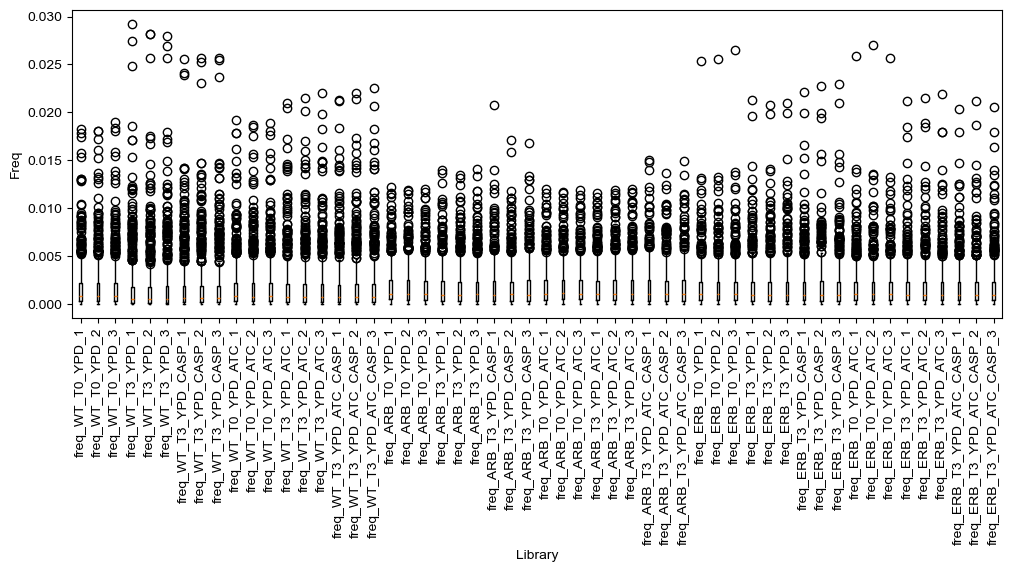

In [10]:
plt.figure(figsize=(12,4))
# create figure and specify size

# let's also look at the distribution of raw abundances for each library

x=0

for col in freq_col_list:
    # loop through freq columns
    
    plt.boxplot(screen_clin_counts[col].dropna(), positions=[x])
    # plot a boxplot for the col
    
    x+=1
    # increment counter by one


plt.xticks(range(0, len(freq_col_list)), freq_col_list, rotation=90)
# label x-ticks

plt.xlabel('Library')
plt.ylabel('Freq')
# format axis labels

In [12]:
background_list = ['WT', 'ARB', 'ERB']
# list genetic backgrounds

drug_list = ['', 'CASP_']
# list drug conditions, including non (YPD)

rep_list = ['1','2','3']
# list of the replicates

log2_col_list = []
# empty container for list of log2-FC columns

count_col=0
# counter

for background in background_list:
    # loop through genetic backgrounds
    for drug in drug_list:
        # loop through drugs
        for rep in rep_list:
            # loop through replicates
            
            ref_col_noATC = 'freq_'+background+'_T0_YPD_'+rep
            ref_col_ATC = 'freq_'+background+'_T0_YPD_ATC_'+rep
            # T0 columns w/ and w/o ATC for the specific genetic background

            strain_col_noATC = 'freq_'+background+'_T3_YPD_'+drug+rep
            log2_col_name_noATC = 'log2fc_'+background+'_'+drug+rep
            # freq column name and new name for log2fc column, w/o ATC
           
            #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)
            # print call for debugging

            strain_col_ATC = 'freq_'+background+'_T3_YPD_ATC_'+drug+rep
            log2_col_name_ATC = 'log2fc_'+background+'_ATC_'+drug+rep
            # freq column name and new name for log2fc column, w/ ATC
            
            # print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)
            # print call for debugging

            log2_col_list.append(log2_col_name_noATC)
            log2_col_list.append(log2_col_name_ATC)
            # append col names to list
            
            screen_clin_counts[log2_col_name_noATC] = np.log2(screen_clin_counts[strain_col_noATC]) - np.log2(screen_clin_counts[ref_col_noATC])
            screen_clin_counts[log2_col_name_ATC] = np.log2(screen_clin_counts[strain_col_ATC]) - np.log2(screen_clin_counts[ref_col_ATC])
            # compute log2 FC and add it to the DataFrame

            count_col+=2
            # increment counter for both w/ and w/o ATC
                
print(count_col)
# print number of columns

screen_clin_counts
# show df with new columns

36


,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_2,log2fc_ERB_ATC_2,log2fc_ERB_3,log2fc_ERB_ATC_3,log2fc_ERB_CASP_1,log2fc_ERB_ATC_CASP_1,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.319649,0.075336,0.603534,0.063506,-0.396387,-0.062987,-0.455223,0.268491,0.692648,-0.270770
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.389088,0.162324,0.403171,0.034016,-0.029998,0.252275,-0.123005,0.241343,0.381692,0.038225
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-0.523482,-0.848043,-1.379978,-0.409936,-0.299656,0.989136,-5.956566,-0.525162,-1.308382,0.074710
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.292598,-0.574605,0.052128,-0.502706,0.562905,-0.539243,-1.049675,-0.449681,0.498495,-0.643179
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.847623,0.209148,1.145126,-0.224332,-0.391578,0.155567,-0.000624,-0.035517,-0.029793,-0.098619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.374244,0.030978,0.489395,0.136863,0.267217,0.052491,0.118377,0.145396,0.093505,-0.056160
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.126482,0.376980,0.269115,0.111944,-0.882535,0.501640,-0.829913,0.004201,-0.247219,0.506592
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.296331,0.348948,0.571201,0.566212,0.708303,0.784730,0.525149,0.548616,0.594143,0.735616
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.400644,0.407472,0.571312,0.660487,0.271068,0.834411,0.213023,0.610501,-0.074295,0.660066


## Filter for low coverage sgRNA

In [13]:
def set_to_nan(log2_fc, count, threshold):
    # Function to apply initial abundance filter to columns: will change values in log2fc for a sgRNA
    # to nan if the value in the count col is below or equal to threshold. Can be applied to a column
    # using a lambda function
    
    #print(log2_fc, count, threshold)
    # debugging print call
    
    if count <= threshold:
        return np.NaN
    elif np.isnan(count)==True:
        return np.NaN
    else:
        return log2_fc

In [14]:
background_list = ['WT', 'ARB', 'ERB']
drug_list = ['', 'CASP_']
rep_list = ['1','2','3']
# list of backgrounds, drugs, and reps

log2_col_list = []
# list of col names

count_col=0

# columns are generated in the same step as filtering to avoid conflicts between df versions

for background in background_list:
    for drug in drug_list:
        for rep in rep_list:
            ref_col_noATC = 'freq_'+background+'_T0_YPD_'+rep
            ref_col_ATC = 'freq_'+background+'_T0_YPD_ATC_'+rep
            count_col+=2

            strain_col_noATC = 'freq_'+background+'_T3_YPD_'+drug+rep
            log2_col_name_noATC = 'log2fc_'+background+'_'+drug+rep

            strain_col_ATC = 'freq_'+background+'_T3_YPD_ATC_'+drug+rep
            log2_col_name_ATC = 'log2fc_'+background+'_ATC_'+drug+rep

            log2_col_list.append(log2_col_name_noATC)
            log2_col_list.append(log2_col_name_ATC)
            # define col names as previously
            
            screen_clin_counts[log2_col_name_noATC] = np.log2(screen_clin_counts[strain_col_noATC]) - np.log2(screen_clin_counts[ref_col_noATC])
            #print(ref_col_noATC, strain_col_noATC, log2_col_name_noATC)
            # debugging print call
            
            screen_clin_counts[log2_col_name_noATC] = screen_clin_counts.apply(lambda x: set_to_nan(x[log2_col_name_noATC], x[(background+'_T0_YPD_'+rep)], 50),axis=1)
            # apply filtering function to column, w/o ATC
            print('dropped '+str(553-len(screen_clin_counts[log2_col_name_noATC].dropna()))+' for column '+log2_col_name_noATC)
            # print number of sgRNA dropped for this w/o ATC column
            
            
            screen_clin_counts[log2_col_name_ATC] = np.log2(screen_clin_counts[strain_col_ATC]) - np.log2(screen_clin_counts[ref_col_ATC])
            #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC, background+'_T0_YPD_ATC_'+rep)
            # debugging print call
            
            screen_clin_counts[log2_col_name_ATC] = screen_clin_counts.apply(lambda x: set_to_nan(x[log2_col_name_ATC], x[(background+'_T0_YPD_ATC_'+rep)], 50),axis=1)
            # apply filtering function to column, w/o ATC
            print('dropped '+str(553-len(screen_clin_counts[log2_col_name_ATC].dropna()))+' for column '+log2_col_name_ATC)
            # print number of sgRNA dropped for this w ATC column
                
print(count_col)
screen_clin_counts

dropped 73 for column log2fc_WT_1
dropped 79 for column log2fc_WT_ATC_1
dropped 67 for column log2fc_WT_2
dropped 73 for column log2fc_WT_ATC_2
dropped 75 for column log2fc_WT_3
dropped 85 for column log2fc_WT_ATC_3
dropped 73 for column log2fc_WT_CASP_1
dropped 79 for column log2fc_WT_ATC_CASP_1
dropped 67 for column log2fc_WT_CASP_2
dropped 73 for column log2fc_WT_ATC_CASP_2
dropped 75 for column log2fc_WT_CASP_3
dropped 85 for column log2fc_WT_ATC_CASP_3
dropped 27 for column log2fc_ARB_1
dropped 26 for column log2fc_ARB_ATC_1
dropped 26 for column log2fc_ARB_2
dropped 31 for column log2fc_ARB_ATC_2
dropped 36 for column log2fc_ARB_3
dropped 23 for column log2fc_ARB_ATC_3
dropped 27 for column log2fc_ARB_CASP_1
dropped 26 for column log2fc_ARB_ATC_CASP_1
dropped 26 for column log2fc_ARB_CASP_2
dropped 31 for column log2fc_ARB_ATC_CASP_2
dropped 36 for column log2fc_ARB_CASP_3
dropped 23 for column log2fc_ARB_ATC_CASP_3
dropped 29 for column log2fc_ERB_1
dropped 65 for column log2fc_

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_2,log2fc_ERB_ATC_2,log2fc_ERB_3,log2fc_ERB_ATC_3,log2fc_ERB_CASP_1,log2fc_ERB_ATC_CASP_1,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.319649,0.075336,0.603534,0.063506,-0.396387,-0.062987,-0.455223,0.268491,0.692648,-0.270770
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.389088,0.162324,0.403171,0.034016,-0.029998,0.252275,-0.123005,0.241343,0.381692,0.038225
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-0.523482,-0.848043,-1.379978,-0.409936,-0.299656,0.989136,-5.956566,-0.525162,-1.308382,0.074710
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.292598,-0.574605,0.052128,-0.502706,0.562905,-0.539243,-1.049675,-0.449681,0.498495,-0.643179
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.847623,0.209148,1.145126,-0.224332,-0.391578,0.155567,-0.000624,-0.035517,-0.029793,-0.098619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.374244,0.030978,0.489395,0.136863,0.267217,0.052491,0.118377,0.145396,0.093505,-0.056160
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.126482,0.376980,0.269115,0.111944,-0.882535,0.501640,-0.829913,0.004201,-0.247219,0.506592
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.296331,0.348948,0.571201,0.566212,0.708303,0.784730,0.525149,0.548616,0.594143,0.735616
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.400644,0.407472,0.571312,0.660487,0.271068,0.834411,0.213023,0.610501,-0.074295,0.660066


In [15]:
screen_clin_counts.loc[97][['log2fc_WT_1', 'log2fc_WT_2', 'log2fc_WT_3', 'WT_T0_YPD_1', 'WT_T0_YPD_2', 'WT_T0_YPD_3']]

log2fc_WT_1    NaN
log2fc_WT_2    NaN
log2fc_WT_3    NaN
WT_T0_YPD_1    NaN
WT_T0_YPD_2    3.0
WT_T0_YPD_3    NaN
Name: 97, dtype: object

(0.5, 1.0)

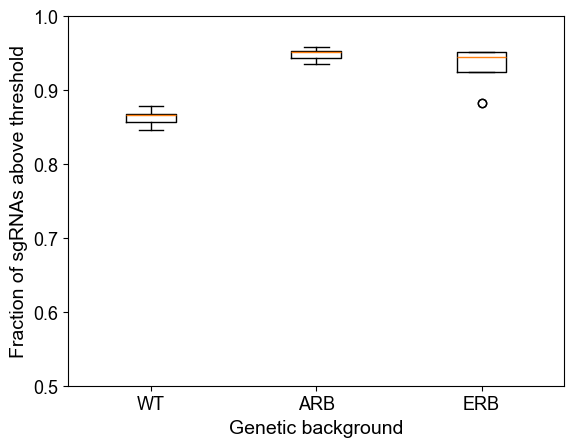

In [16]:
sgRNA_passing_filter_dists = [[len(screen_clin_counts[x].dropna())/553 for x in log2_col_list if 'WT' in x],
                             [len(screen_clin_counts[x].dropna())/553 for x in log2_col_list if 'ARB' in x],
                             [len(screen_clin_counts[x].dropna())/553 for x in log2_col_list if 'ERB' in x]]
# for all samples in the WT, ARB or ERB backgrounds, get the number of sgRNAs that passed the initial
# abundance threshold

plt.boxplot(sgRNA_passing_filter_dists)
# make boxplot with lists of values


plt.xticks([1,2,3], ['WT', 'ARB', 'ERB'], fontsize=13)
plt.xlabel('Genetic background', fontsize=14)
plt.yticks(fontsize=13)
plt.ylabel('Fraction of sgRNAs above threshold', fontsize=14)
plt.ylim(0.5,1)
# format plot

In [17]:
screen_clin_counts[log2_col_list].dropna()
# check how many sgRNAs have no missing values across all samples

,log2fc_WT_1,log2fc_WT_ATC_1,log2fc_WT_2,log2fc_WT_ATC_2,log2fc_WT_3,log2fc_WT_ATC_3,log2fc_WT_CASP_1,log2fc_WT_ATC_CASP_1,log2fc_WT_CASP_2,log2fc_WT_ATC_CASP_2,...,log2fc_ERB_2,log2fc_ERB_ATC_2,log2fc_ERB_3,log2fc_ERB_ATC_3,log2fc_ERB_CASP_1,log2fc_ERB_ATC_CASP_1,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3
0,0.889394,0.192991,0.765472,-0.047677,0.690828,0.238882,0.916132,-0.012968,0.923338,0.179789,...,0.319649,0.075336,0.603534,0.063506,-0.396387,-0.062987,-0.455223,0.268491,0.692648,-0.270770
1,0.331663,-0.106586,0.442207,0.111240,0.432387,0.099135,0.497956,0.080577,0.281380,0.088557,...,0.389088,0.162324,0.403171,0.034016,-0.029998,0.252275,-0.123005,0.241343,0.381692,0.038225
3,0.429490,0.043140,0.183954,-0.571270,0.071302,-0.285412,1.116987,0.476755,0.515384,0.154163,...,-0.292598,-0.574605,0.052128,-0.502706,0.562905,-0.539243,-1.049675,-0.449681,0.498495,-0.643179
4,-0.141380,-0.100171,0.166958,0.227650,0.181069,-0.105098,-2.218031,-0.301333,-1.687310,-0.152787,...,0.847623,0.209148,1.145126,-0.224332,-0.391578,0.155567,-0.000624,-0.035517,-0.029793,-0.098619
5,-0.335211,-0.433090,-0.076960,-0.275179,-0.284259,-0.464502,-1.394355,-0.385741,-1.668442,-0.456061,...,0.324035,0.018689,0.279073,0.167782,0.819414,0.241391,0.292326,0.140694,0.657054,0.182747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,0.428099,-0.048754,0.494946,-0.013540,0.429547,0.057602,0.057134,-0.057370,0.073873,0.080685,...,0.374244,0.030978,0.489395,0.136863,0.267217,0.052491,0.118377,0.145396,0.093505,-0.056160
549,0.541622,0.337234,0.588085,0.129163,0.502975,0.290474,-0.030320,0.026390,0.288843,0.132375,...,0.126482,0.376980,0.269115,0.111944,-0.882535,0.501640,-0.829913,0.004201,-0.247219,0.506592
550,0.022850,-0.040087,-0.059959,0.011416,-0.005394,0.005427,0.053919,-0.079834,0.008611,0.055861,...,0.296331,0.348948,0.571201,0.566212,0.708303,0.784730,0.525149,0.548616,0.594143,0.735616
551,-0.615417,-0.416577,-1.051490,-0.076378,-0.893084,-0.243982,-0.478342,-0.102326,-0.805962,0.000129,...,0.400644,0.407472,0.571312,0.660487,0.271068,0.834411,0.213023,0.610501,-0.074295,0.660066


## ON correlation for the three backgrounds

In [18]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

### WT

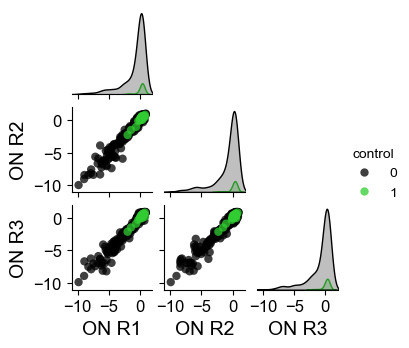

In [19]:
with sns.plotting_context(rc={"axes.labelsize":14, 'xtick.labelsize': 12, 'ytick.labelsize': 12}):

    p = sns.pairplot(screen_clin_counts[is_control|is_test], vars =['log2fc_WT_1',  'log2fc_WT_2', 'log2fc_WT_3'], diag_kind='kde', corner=True,
                    hue='control', palette={1:'limegreen',0:'k'}, plot_kws={'linewidth':0, 'alpha':0.75}, height=3.5/3)
    p.set(xlim=(-11,2), ylim=(-11,2), xticks=([-10,-5,0]), yticks=([-10,-5,0]))
    #p.tick_params(axis='both', )
    
    p.x_vars = ['ON R1', 'ON R2', 'ON R3']
    p.y_vars = ['ON R1', 'ON R2', 'ON R3']
    p._add_axis_labels()
    
    plt.savefig('./figures/timecourse_rep_scatterplot_ON_screen_clin_WT.svg', dpi=300)

In [20]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_WT_1'],
                screen_clin_counts[is_control|is_test]['log2fc_WT_2'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_WT_1', 'log2fc_WT_2']].dropna())

(SignificanceResult(statistic=0.9023353707149745, pvalue=5.407189022516284e-175),
 475)

In [21]:
len(screen_clin_counts[is_control][['log2fc_WT_1', 'log2fc_WT_2']].dropna()), len(screen_clin_counts[is_test][['log2fc_WT_1', 'log2fc_WT_2']].dropna())

(29, 446)

In [22]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_WT_1'],
                screen_clin_counts[is_control|is_test]['log2fc_WT_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_WT_1', 'log2fc_WT_3']].dropna())

(SignificanceResult(statistic=0.8862582368423142, pvalue=1.5509888940393022e-159),
 473)

In [23]:
len(screen_clin_counts[is_control][['log2fc_WT_1', 'log2fc_WT_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_WT_1', 'log2fc_WT_3']].dropna())

(29, 444)

In [24]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_WT_2'],
                screen_clin_counts[is_control|is_test]['log2fc_WT_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_WT_2', 'log2fc_WT_3']].dropna())

(SignificanceResult(statistic=0.8840232883261697, pvalue=5.368897829163029e-158),
 474)

In [25]:
len(screen_clin_counts[is_control][['log2fc_WT_2', 'log2fc_WT_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_WT_2', 'log2fc_WT_3']].dropna())

(29, 445)

### FLUr

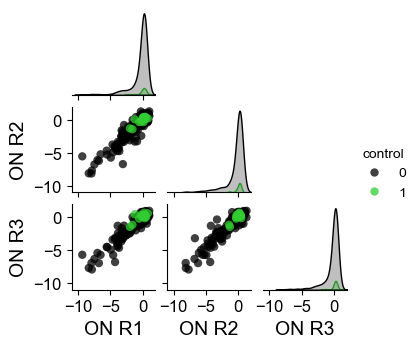

In [26]:
with sns.plotting_context(rc={"axes.labelsize":14, 'xtick.labelsize': 12, 'ytick.labelsize': 12}):

    p = sns.pairplot(screen_clin_counts[is_control|is_test], vars =['log2fc_ARB_1',  'log2fc_ARB_2', 'log2fc_ARB_3'], diag_kind='kde', corner=True,
                    hue='control', palette={1:'limegreen',0:'k'}, plot_kws={'linewidth':0, 'alpha':0.75}, height=3.5/3)
    p.set(xlim=(-11,2), ylim=(-11,2), xticks=([-10,-5,0]), yticks=([-10,-5,0]))
    #p.tick_params(axis='both', )
    
    p.x_vars = ['ON R1', 'ON R2', 'ON R3']
    p.y_vars = ['ON R1', 'ON R2', 'ON R3']
    p._add_axis_labels()
    
    
    plt.savefig('./figures/timecourse_rep_scatterplot_ON_screen_clin_FLUr.svg', dpi=300)

In [27]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ARB_1'],
                screen_clin_counts[is_control|is_test]['log2fc_ARB_2'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ARB_1', 'log2fc_ARB_2']].dropna())

(SignificanceResult(statistic=0.7453131260868768, pvalue=5.841923412641974e-94),
 524)

In [28]:
len(screen_clin_counts[is_control][['log2fc_ARB_1', 'log2fc_ARB_2']].dropna()), len(screen_clin_counts[is_test][['log2fc_ARB_1', 'log2fc_ARB_2']].dropna())

(28, 496)

In [29]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ARB_1'],
                screen_clin_counts[is_control|is_test]['log2fc_ARB_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ARB_1', 'log2fc_ARB_3']].dropna())

(SignificanceResult(statistic=0.6908806757513934, pvalue=2.7207045317975713e-74),
 515)

In [30]:
len(screen_clin_counts[is_control][['log2fc_ARB_1', 'log2fc_ARB_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_ARB_1', 'log2fc_ARB_3']].dropna())

(28, 487)

In [31]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ARB_2'],
                screen_clin_counts[is_control|is_test]['log2fc_ARB_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ARB_2', 'log2fc_ARB_3']].dropna())

(SignificanceResult(statistic=0.7286222275988837, pvalue=2.3189975382592535e-86),
 515)

In [32]:
len(screen_clin_counts[is_control][['log2fc_ARB_2', 'log2fc_ARB_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_ARB_2', 'log2fc_ARB_3']].dropna())

(28, 487)

In [33]:
sns.plotting_context()


{'font.size': 10.0,
 'axes.labelsize': 'medium',
 'axes.titlesize': 'large',
 'xtick.labelsize': 'medium',
 'ytick.labelsize': 'medium',
 'legend.fontsize': 'medium',
 'legend.title_fontsize': None,
 'axes.linewidth': 0.8,
 'grid.linewidth': 0.8,
 'lines.linewidth': 1.5,
 'lines.markersize': 6.0,
 'patch.linewidth': 1.0,
 'xtick.major.width': 0.8,
 'ytick.major.width': 0.8,
 'xtick.minor.width': 0.6,
 'ytick.minor.width': 0.6,
 'xtick.major.size': 3.5,
 'ytick.major.size': 3.5,
 'xtick.minor.size': 2.0,
 'ytick.minor.size': 2.0}

#### CASPr

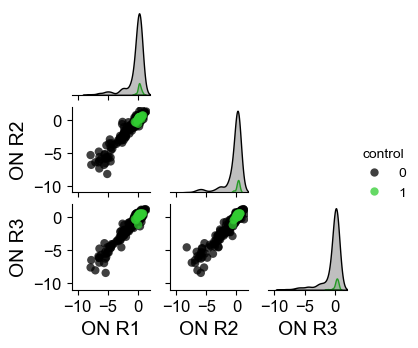

In [34]:

with sns.plotting_context(rc={"axes.labelsize":14, 'xtick.labelsize': 12, 'ytick.labelsize': 12}):

    p = sns.pairplot(screen_clin_counts[is_control|is_test], vars =['log2fc_ERB_1',  'log2fc_ERB_2', 'log2fc_ERB_3'], diag_kind='kde', corner=True,
                    hue='control', palette={1:'limegreen',0:'k'}, plot_kws={'linewidth':0, 'alpha':0.75}, height=3.5/3)
    p.set(xlim=(-11,2), ylim=(-11,2), xticks=([-10,-5,0]), yticks=([-10,-5,0]))
    #p.tick_params(axis='both', )
    
    p.x_vars = ['ON R1', 'ON R2', 'ON R3']
    p.y_vars = ['ON R1', 'ON R2', 'ON R3']
    p._add_axis_labels()



plt.savefig('./figures/timecourse_rep_scatterplot_ON_screen_clin_CASPr.svg', dpi=300)

In [35]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ERB_1'],
                screen_clin_counts[is_control|is_test]['log2fc_ERB_2'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ERB_1', 'log2fc_ERB_2']].dropna())

(SignificanceResult(statistic=0.8763962960093665, pvalue=8.148747698125773e-167),
 521)

In [36]:
len(screen_clin_counts[is_control][['log2fc_ERB_1', 'log2fc_ERB_2']].dropna()), len(screen_clin_counts[is_test][['log2fc_ERB_1', 'log2fc_ERB_2']].dropna())

(28, 493)

In [37]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ERB_1'],
                screen_clin_counts[is_control|is_test]['log2fc_ERB_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ERB_1', 'log2fc_ERB_3']].dropna())

(SignificanceResult(statistic=0.8478389482308938, pvalue=1.4944247948321412e-144),
 519)

In [38]:
len(screen_clin_counts[is_control][['log2fc_ERB_1', 'log2fc_ERB_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_ERB_1', 'log2fc_ERB_3']].dropna())

(28, 491)

In [39]:
stats.spearmanr(screen_clin_counts[is_control|is_test]['log2fc_ERB_2'],
                screen_clin_counts[is_control|is_test]['log2fc_ERB_3'], nan_policy='omit'), len(screen_clin_counts[is_control|is_test][['log2fc_ERB_2', 'log2fc_ERB_3']].dropna())

(SignificanceResult(statistic=0.8558313960179516, pvalue=3.958880630742193e-150),
 519)

In [40]:
len(screen_clin_counts[is_control][['log2fc_ERB_2', 'log2fc_ERB_3']].dropna()), len(screen_clin_counts[is_test][['log2fc_ERB_2', 'log2fc_ERB_3']].dropna())

(28, 491)

In [41]:
screen_clin_counts[['log2fc_ERB_1',  'log2fc_ERB_2', 'log2fc_ERB_3','log2fc_ARB_1',  'log2fc_ARB_2', 'log2fc_ARB_3','log2fc_WT_1',  'log2fc_WT_2', 'log2fc_WT_3']].max().max()

1.6075036269313507

### Overall ON/OFF correlations

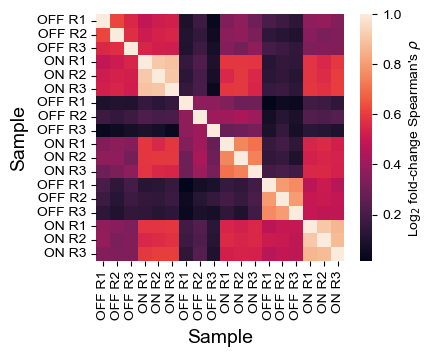

In [42]:
plt.figure(figsize=(4,3.2))

sns.heatmap(screen_clin_counts[[ 'log2fc_WT_ATC_1',  'log2fc_WT_ATC_2', 'log2fc_WT_ATC_3', 
                              'log2fc_WT_1', 'log2fc_WT_2', 'log2fc_WT_3',
                              'log2fc_ARB_ATC_1', 'log2fc_ARB_ATC_2', 'log2fc_ARB_ATC_3',
                              'log2fc_ARB_1', 'log2fc_ARB_2', 'log2fc_ARB_3',
                              'log2fc_ERB_ATC_1', 'log2fc_ERB_ATC_2', 'log2fc_ERB_ATC_3',
                              'log2fc_ERB_1', 'log2fc_ERB_2', 'log2fc_ERB_3'
                    ]].dropna().corr(method='spearman'), cbar_kws={'label':r"Log$_{2}$ fold-change Spearman's $\rho$"})


plt.xticks([x+0.5 for x in range(0, 18)], ['OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3',
                                           'OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3',
                                           'OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3'])

plt.xlabel('Sample', fontsize=14)



plt.yticks([x+0.5 for x in range(0, 18)], ['OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3',
                                           'OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3',
                                           'OFF R1',' OFF R2','OFF R3',
                                           'ON R1',' ON R2','ON R3'])

plt.ylabel('Sample', fontsize=14)

plt.savefig('./figures/backgrounds_screen_corr.svg', format='svg', dpi=300, bbox_inches='tight')



In [43]:
436/553
# fraction with full coverage

0.7884267631103075

In [44]:
screen_clin_counts.columns

Index(['Gene', 'alias', 'SgRNA', 'Barcode', 'control', 'strand', 'atg_dist',
       'B_mismatch', 'dist_TSS', 'abs_TSS_dist',
       ...
       'log2fc_ERB_2', 'log2fc_ERB_ATC_2', 'log2fc_ERB_3', 'log2fc_ERB_ATC_3',
       'log2fc_ERB_CASP_1', 'log2fc_ERB_ATC_CASP_1', 'log2fc_ERB_CASP_2',
       'log2fc_ERB_ATC_CASP_2', 'log2fc_ERB_CASP_3', 'log2fc_ERB_ATC_CASP_3'],
      dtype='object', length=179)

## Compute median log2FC values for WT background

In [45]:
backgrounds = ['WT', 'ARB', 'ERB']
inducer = ['', '_ATC']
# list of drugs, reps and ATC status

for background in backgrounds:
    for induc in inducer:
        # loop through columns
        
        col_name_base = 'log2fc_'+background+induc
        print(col_name_base)
        # base name of columns to compute the median 

        screen_clin_counts[col_name_base+'_median'] = screen_clin_counts[[(col_name_base+'_1'), (col_name_base+'_2'), (col_name_base+'_3')]].median(axis=1)
        print(col_name_base+'_median')
        # compute median using pandas method, axis=1 specifies median is to be computed across columns

log2fc_WT
log2fc_WT_median
log2fc_WT_ATC
log2fc_WT_ATC_median
log2fc_ARB
log2fc_ARB_median
log2fc_ARB_ATC
log2fc_ARB_ATC_median
log2fc_ERB
log2fc_ERB_median
log2fc_ERB_ATC
log2fc_ERB_ATC_median


In [46]:
screen_clin_counts['log2fc_ARB_median']

0      0.516476
1      0.328640
2           NaN
3     -0.093210
4      0.390679
         ...   
548    0.267046
549    0.391936
550    0.053546
551   -0.333870
552    0.230639
Name: log2fc_ARB_median, Length: 553, dtype: float64

In [47]:
for background in backgrounds:
    for induc in inducer:
        col_name_base = 'log2fc_'+background+induc
        median_col_name = col_name_base+'_median'
        
        n_nans = screen_clin_counts[[(col_name_base+'_1'),(col_name_base+'_2'),(col_name_base+'_3')]].isnull().sum(axis=1)
        above_0_nan = list(n_nans[n_nans>0].index)
        print(median_col_name, len(above_0_nan))
        
        for row in above_0_nan:
            screen_clin_counts.at[row,median_col_name]=np.nan

log2fc_WT_median 80
log2fc_WT_ATC_median 89
log2fc_ARB_median 36
log2fc_ARB_ATC_median 33
log2fc_ERB_median 32
log2fc_ERB_ATC_median 65


In [48]:
[len(screen_clin_counts[is_control|is_test]['log2fc_WT_median'].dropna()), 
 len(screen_clin_counts[is_control|is_test]['log2fc_ARB_median'].dropna()), 
 len(screen_clin_counts[is_control|is_test]['log2fc_ERB_median'].dropna())]

[471, 515, 519]

In [49]:
coverage_fraction_list = [len(screen_clin_counts[is_control|is_test]['log2fc_WT_median'].dropna())/551,
                          len(screen_clin_counts[is_control|is_test]['log2fc_ARB_median'].dropna())/551, 
                          len(screen_clin_counts[is_control|is_test]['log2fc_ERB_median'].dropna())/551,
                          len(screen_clin_counts[is_control|is_test][['log2fc_WT_median', 'log2fc_ERB_median', 'log2fc_ARB_median']].dropna())/551]
coverage_fraction_list

[0.8548094373865699, 0.9346642468239564, 0.941923774954628, 0.8203266787658802]

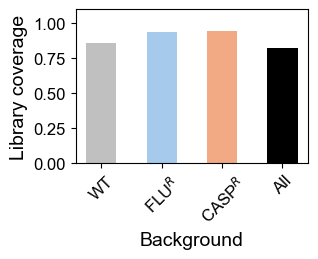

In [50]:
plt.figure(figsize=(3,2))
plt.bar([1, 2 , 3, 4], coverage_fraction_list, color = ['silver', '#A6CAEC', '#F2AA84', 'k'], width=0.5)

plt.ylabel('Library coverage', fontsize=14)
plt.ylim(0,1.1)
plt.yticks(fontsize=12)
plt.xticks([1, 2 , 3, 4], ['WT', 'FLU$^{R}$', 'CASP$^{R}$', 'All'], fontsize=12, rotation=45)
plt.xlabel('Background', fontsize=14)

plt.savefig('./figures/library_coverage.svg', dpi=300, format='svg')

In [51]:
len(screen_clin_counts)

553

In [52]:
screen_clin_counts['log2fc_ARB_median']

0      0.516476
1      0.328640
2           NaN
3     -0.093210
4      0.390679
         ...   
548    0.267046
549    0.391936
550    0.053546
551   -0.333870
552    0.230639
Name: log2fc_ARB_median, Length: 553, dtype: float64

In [53]:
screen_clin_counts.loc[97]

Gene                                C1_09030C
alias                                    COX5
SgRNA                                      98
Barcode                  TAGTTAGTGGGATTTGGTAC
control                                     0
                                 ...         
log2fc_WT_ATC_median                      NaN
log2fc_ARB_median                         NaN
log2fc_ARB_ATC_median                     NaN
log2fc_ERB_median                   -1.837255
log2fc_ERB_ATC_median               -2.321497
Name: 97, Length: 185, dtype: object

In [54]:
screen_clin_counts.at[539, 'control'] = 2
# exclude sgRNA-R18 from test values due to its outlier status across multiple experiments and genetic backgrounds.

## Threshold for WT no ATC

In [55]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

In [56]:
wt_on_mean, wt_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_WT_median'].dropna())
wt_on_mean, wt_on_scale

(0.14380888439270667, 0.6219529695962892)

-2.0844001078356396 0.00017009536406099917 76 0.17194570135746606 0.0009892388278284424
-1.26207764334419 0.011897020167429205 107 0.2420814479638009 0.04914470013087578


Text(0, 0.5, 'FDR')

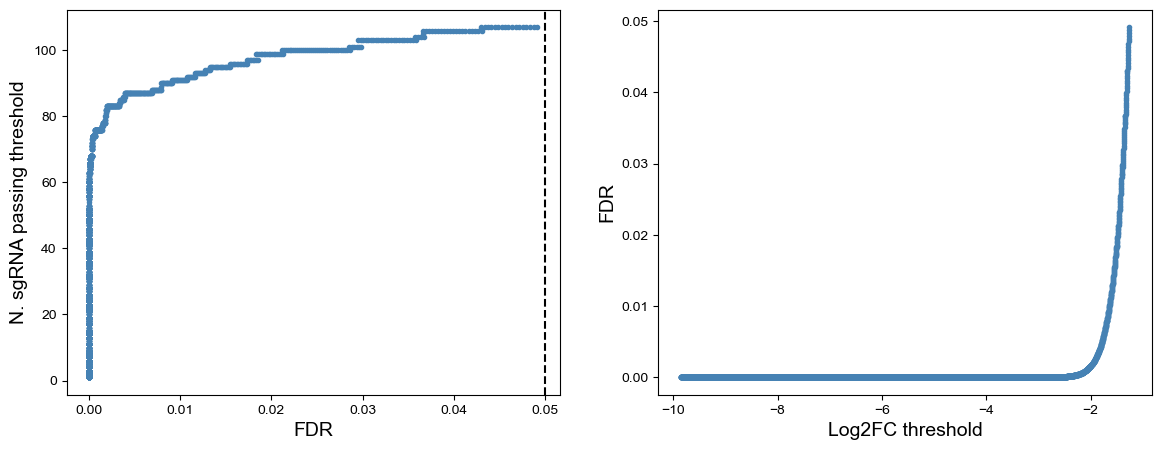

In [57]:
target_col = 'log2fc_WT_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=wt_on_mean, scale=wt_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.00098 and FDR <0.001:
        print(val, FPR, positives, PR, FDR) 
   

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [58]:
threshold_wt_on = -1.26207764334419

In [59]:
below_wt_on_threshold = screen_clin_counts['log2fc_WT_median'] < -1.26207764334419
below_wt_on_threshold_stringent = screen_clin_counts['log2fc_WT_median'] < -2.0844001078356396

In [60]:
screen_clin_hits_WT = screen_clin_counts[is_test&below_wt_on_threshold]
screen_clin_hits_WT

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3,log2fc_WT_median,log2fc_WT_ATC_median,log2fc_ARB_median,log2fc_ARB_ATC_median,log2fc_ERB_median,log2fc_ERB_ATC_median
13,C1_00510W,C1_00510W,14,ATCTCGTTCCCCAACAAGTT,0,+,133.0,no,-69.0,69.0,...,-0.318720,-0.350371,0.052807,-0.566266,-2.250874,-0.562132,0.077652,0.010553,0.060341,-0.216462
14,C1_00510W,C1_00510W,15,TCTCGTTCCCCAACAAGTTA,0,+,132.0,no,-68.0,68.0,...,0.433100,0.340040,0.276627,0.196602,-2.863618,-0.546125,0.226721,0.003336,0.229075,0.293606
23,C1_01600W,MRP20,24,GTGGTGCAAGGTTGATTGAA,0,+,230.0,no,-201.0,201.0,...,-0.542809,-0.718100,-0.616717,-0.227172,-1.609075,0.072204,-0.258390,0.028631,-0.603424,-0.422076
24,C1_01950C,C1_01950C,25,ATACTTGAGGTAGTGTATGG,0,+,142.0,no,-115.0,115.0,...,-2.009507,-1.040718,-3.517167,-3.221425,-2.269128,-0.321729,-1.184937,0.120662,-1.268515,-0.458589
32,C1_02510W,C1_02510W,33,TGAACTTAGAGTCCGTATAC,0,+,144.0,no,-83.0,83.0,...,0.378720,0.196345,-0.245550,-0.032511,-1.969441,0.147208,-0.503991,0.043715,-0.267717,0.218451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,CR_04140W,CR_04140W,484,GTTGTGTTTGACCTATAGGT,0,-,38.0,yes,13.0,13.0,...,-1.240927,-0.091689,-0.900806,-0.078182,-2.397791,0.037919,0.341015,0.131629,-1.989711,0.166294
487,CR_05100W,BIR1,490,CGTGCAACGCCAATACATTA,0,+,162.0,no,-107.0,107.0,...,0.281351,0.191135,0.016259,0.015426,-1.834000,0.007465,-1.208892,-0.420584,-0.647469,-0.011066
494,CR_07390C,MRPL8,497,GCTATAACGTTACTAGTAGT,0,-,141.0,no,-114.0,114.0,...,-0.470305,-0.114073,-0.567439,-0.492680,-1.518181,-0.175400,0.039094,-0.180214,-0.501333,-0.776944
497,CR_07390C,MRPL8,500,TAGGGTTGATTAAAAGAGAA,0,-,21.0,no,6.0,6.0,...,-0.574346,-0.096594,-0.310956,-0.166849,-1.983199,-0.274581,-0.075223,0.102947,-0.576708,-0.029968


In [61]:
len(screen_clin_counts[is_control]['log2fc_WT_median'].dropna()), len(screen_clin_counts[is_test]['log2fc_WT_median'].dropna())

(29, 442)

In [62]:
screen_clin_counts[['log2fc_WT_median', 'log2fc_ARB_median', 'log2fc_ERB_median']].max(), screen_clin_counts[['log2fc_WT_median', 'log2fc_ARB_median', 'log2fc_ERB_median']].min()

(log2fc_WT_median     0.928312
 log2fc_ARB_median    1.038503
 log2fc_ERB_median    1.256044
 dtype: float64,
 log2fc_WT_median    -9.868010
 log2fc_ARB_median   -8.125950
 log2fc_ERB_median   -7.625703
 dtype: float64)

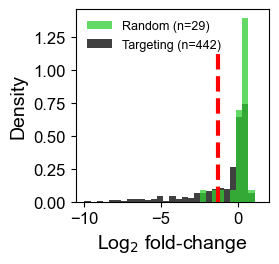

In [63]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_WT_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_WT_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=29)', 'Targeting (n=442)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_wt_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



plt.savefig('./figures/cumulative_dist_WT.svg', dpi=300, format='svg')

## Threshold for FLUR no ATC

In [64]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

In [65]:
ARB_on_mean, ARB_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_ARB_median'].dropna())
ARB_on_mean, ARB_on_scale

(0.06401949196386557, 0.4588537969048132)

-1.6300087969291441 0.00011130589022482484 55 0.11293634496919917 0.000985563064354358
-1.628385282191167 0.00011286485230571177 55 0.11293634496919917 0.0009993669649614842
-1.0504140354712712 0.00757583527877479 75 0.1540041067761807 0.04919242374351097


Text(0, 0.5, 'FDR')

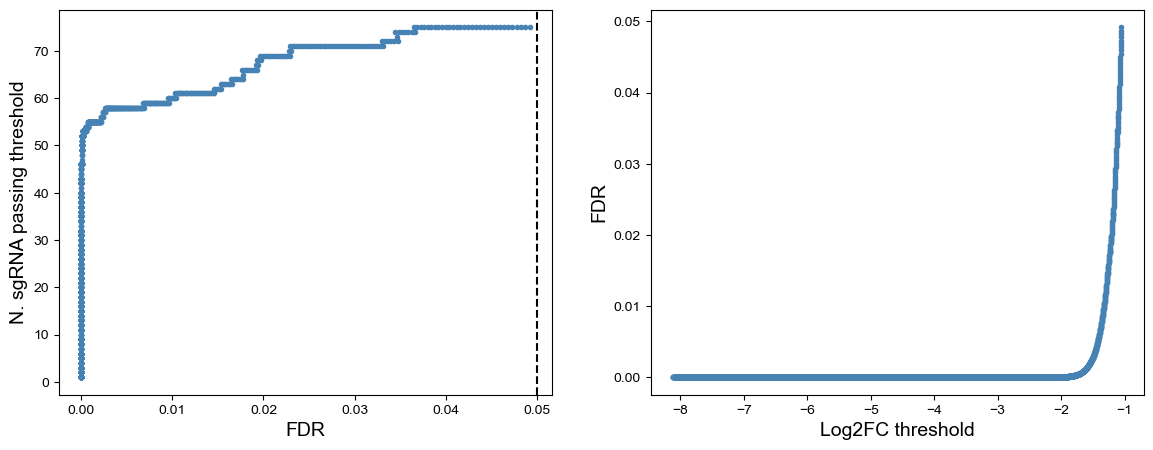

In [66]:
target_col = 'log2fc_ARB_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=ARB_on_mean, scale=ARB_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.00098 and FDR <0.001:
        print(val, FPR, positives, PR, FDR) 

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [67]:
threshold_ARB_on = -1.0504140354712712

In [68]:
below_ARB_on_threshold = screen_clin_counts['log2fc_ARB_median'] < -1.0504140354712712
below_ARB_on_threshold_stringent = screen_clin_counts['log2fc_ARB_median'] < -1.628385282191167


In [69]:
screen_clin_hits_ARB = screen_clin_counts[is_test&below_ARB_on_threshold]
screen_clin_hits_ARB

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3,log2fc_WT_median,log2fc_WT_ATC_median,log2fc_ARB_median,log2fc_ARB_ATC_median,log2fc_ERB_median,log2fc_ERB_ATC_median
24,C1_01950C,C1_01950C,25,ATACTTGAGGTAGTGTATGG,0,+,142.0,no,-115.0,115.0,...,-2.009507,-1.040718,-3.517167,-3.221425,-2.269128,-0.321729,-1.184937,0.120662,-1.268515,-0.458589
60,C1_05500W,RSM22,61,TAAGACACAAAAGTGGAAAC,0,+,94.0,no,NaN,NaN,...,-0.323175,0.116188,-0.136761,0.040863,-1.973944,-0.598786,-1.258807,-0.087592,-1.498786,0.253353
61,C1_05500W,RSM22,62,ACACAAAAGTGGAAACAGGA,0,+,90.0,no,NaN,NaN,...,-2.682097,-0.993123,-2.216196,-1.428768,-6.593552,-1.527080,-4.677746,-0.911593,-5.490480,-0.870375
85,C1_07600W,ATP7,86,ATGGTTGTAAGAATTTGTGT,0,-,62.0,no,0.0,0.0,...,-1.582218,-0.467667,-1.457798,-0.795360,0.657165,0.004641,-3.114179,-0.086917,-2.589408,-0.562921
92,C1_08920W,C1_08920W,93,TTCTTCCTTCGATTACCCAT,0,-,85.0,no,-48.0,48.0,...,-6.405324,-3.031258,-5.587385,-1.516691,NaN,NaN,-3.887226,-2.146448,-5.891103,-1.582668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,CR_04520W,MIM1,487,TGTATAAGTAAATAAAAATC,0,-,65.0,no,-24.0,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.217445,0.297110,NaN,NaN
487,CR_05100W,BIR1,490,CGTGCAACGCCAATACATTA,0,+,162.0,no,-107.0,107.0,...,0.281351,0.191135,0.016259,0.015426,-1.834000,0.007465,-1.208892,-0.420584,-0.647469,-0.011066
488,CR_05100W,BIR1,491,GTGCAACGCCAATACATTAC,0,+,161.0,no,-106.0,106.0,...,0.480208,0.609613,-1.100981,0.458379,-1.071053,-0.168667,-2.788483,-0.047356,-2.550507,0.370115
515,CR_10650W,LTV1,518,AAATTTGGTATGGAGATGAG,0,+,220.0,no,-203.0,203.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.883167,0.107962,NaN,NaN


In [70]:
len(screen_clin_counts[is_control]['log2fc_ARB_median'].dropna()), len(screen_clin_counts[is_test]['log2fc_ARB_median'].dropna())

(28, 487)

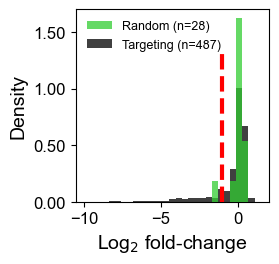

In [71]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_ARB_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_ARB_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=28)', 'Targeting (n=487)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_ARB_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks([0.00,0.50,1.00,1.50], ['0.00','0.50','1.00','1.50'], fontsize=12)

plt.savefig('./figures/cumulative_dist_FLUR.svg', dpi=300, format='svg')

## Threshold for CASPR no ATC

In [72]:
ERB_on_mean, ERB_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_ERB_median'].dropna())
ERB_on_mean, ERB_on_scale

(0.20367087403005382, 0.28814908909314263)

-0.8226604705965119 0.00018415578930408788 92 0.18737270875763748 0.000982831440742469
-0.4463694775644038 0.012037923200320605 119 0.24236252545824846 0.04966907807863376


Text(0, 0.5, 'FDR')

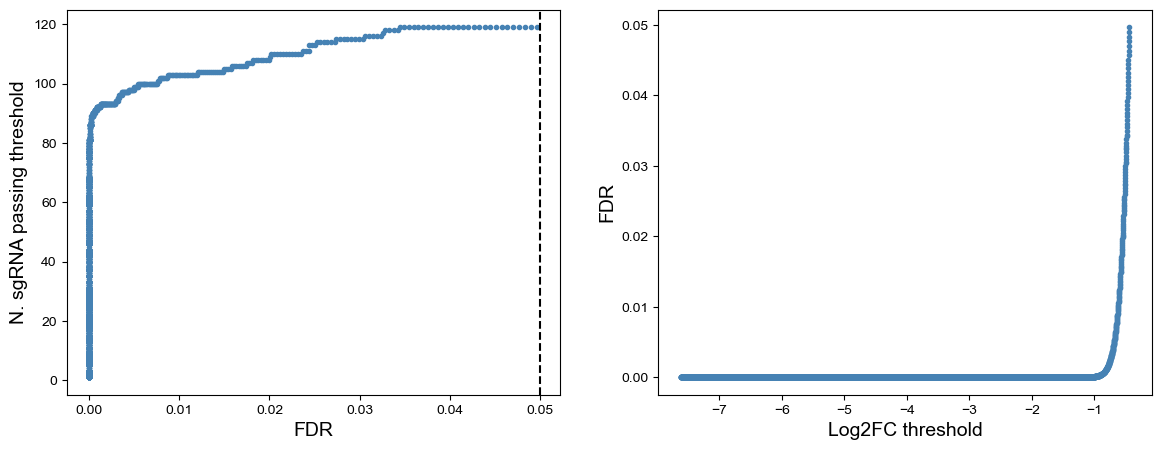

In [73]:
target_col = 'log2fc_ERB_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=ERB_on_mean, scale=ERB_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.00098 and FDR <0.001:
        print(val, FPR, positives, PR, FDR) 

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [74]:
threshold_ERB_on = -0.4463694775644038

In [75]:
below_ERB_on_threshold = screen_clin_counts['log2fc_ERB_median'] < -0.4463694775644038
below_ERB_on_threshold_stringent = screen_clin_counts['log2fc_ERB_median'] < -0.8226604705965119


In [76]:
screen_clin_hits_ERB = screen_clin_counts[is_test&below_ERB_on_threshold]
screen_clin_hits_ERB

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3,log2fc_WT_median,log2fc_WT_ATC_median,log2fc_ARB_median,log2fc_ARB_ATC_median,log2fc_ERB_median,log2fc_ERB_ATC_median
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-5.956566,-0.525162,-1.308382,0.074710,NaN,NaN,NaN,NaN,-0.523482,-0.409936
19,C1_01070C,KRP1,20,ATATAAGAACCCGATACTAT,0,+,209.0,no,-102.0,102.0,...,-6.758340,-5.876088,-5.203610,-5.547962,NaN,NaN,NaN,NaN,-6.244119,NaN
23,C1_01600W,MRP20,24,GTGGTGCAAGGTTGATTGAA,0,+,230.0,no,-201.0,201.0,...,-0.542809,-0.718100,-0.616717,-0.227172,-1.609075,0.072204,-0.258390,0.028631,-0.603424,-0.422076
24,C1_01950C,C1_01950C,25,ATACTTGAGGTAGTGTATGG,0,+,142.0,no,-115.0,115.0,...,-2.009507,-1.040718,-3.517167,-3.221425,-2.269128,-0.321729,-1.184937,0.120662,-1.268515,-0.458589
41,C1_02660C,MGM101,42,TAAATTACACAGCTTTAAGG,0,+,148.0,no,-93.0,93.0,...,-0.099727,0.152742,-0.112538,0.519232,-2.236087,-0.300893,-0.739635,0.028295,-0.969040,0.261902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,CR_07390C,MRPL8,497,GCTATAACGTTACTAGTAGT,0,-,141.0,no,-114.0,114.0,...,-0.470305,-0.114073,-0.567439,-0.492680,-1.518181,-0.175400,0.039094,-0.180214,-0.501333,-0.776944
497,CR_07390C,MRPL8,500,TAGGGTTGATTAAAAGAGAA,0,-,21.0,no,6.0,6.0,...,-0.574346,-0.096594,-0.310956,-0.166849,-1.983199,-0.274581,-0.075223,0.102947,-0.576708,-0.029968
518,C7_02030W,HSP90,521,ATTTTTCCAGTGGTCTCCGT,0,+,131.0,no,-99.0,99.0,...,0.335943,0.169976,1.124577,0.424976,NaN,NaN,NaN,NaN,-0.528347,NaN
519,C7_02030W,HSP90,522,TGGCAACCAACGGAGACCAC,0,-,122.0,no,-90.0,90.0,...,0.211700,0.331708,-0.077927,-0.081821,NaN,NaN,-1.318391,-0.061775,-1.135944,-0.565148


In [77]:
len(screen_clin_counts[is_control]['log2fc_ERB_median'].dropna()), len(screen_clin_counts[is_test]['log2fc_ERB_median'].dropna())

(28, 491)

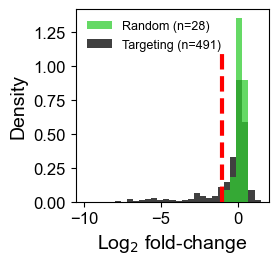

In [78]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_ERB_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_ERB_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=28)', 'Targeting (n=491)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_ARB_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('./figures/cumulative_dist_ERB.svg', dpi=300, format='svg')

### bars for upset plot

In [79]:
hit_genes_WT = list(screen_clin_hits_WT.alias.unique())
hit_genes_ARB = list(screen_clin_hits_ARB.alias.unique())
hit_genes_ERB = list(screen_clin_hits_ERB.alias.unique())
len(hit_genes_WT), len(hit_genes_ARB), len(hit_genes_ERB)

(60, 46, 67)

In [80]:
all_genes = list(set(hit_genes_WT+hit_genes_ARB+hit_genes_ERB))
len(all_genes)

78

In [81]:
dist_types = Counter()

all_background_hits = []

for gene in all_genes:

    val=0

    if gene in hit_genes_WT:
        val+=100
    if gene in hit_genes_ARB:
        val+=10
    if gene in hit_genes_ERB:
        val+=1

    if val == 111:
        all_background_hits.append(gene)

    if val == 101:
        print('WT-CASPR', gene)

    if val == 11:
        print('FLUR-CASPR', gene)


    dist_types[val]+=1

dist_types

WT-CASPR NPL6
WT-CASPR C1_13370W
WT-CASPR C1_03280W
FLUR-CASPR C2_01030W
WT-CASPR RRP15
FLUR-CASPR GLE1
WT-CASPR MRPL8
WT-CASPR LIG1
FLUR-CASPR PET100
WT-CASPR C3_07390C
FLUR-CASPR CR_03430W
WT-CASPR MGM101
FLUR-CASPR C7_03000C
WT-CASPR RIB4
WT-CASPR MDS3
WT-CASPR TIM54
WT-CASPR SPC19
FLUR-CASPR C4_04820C
WT-CASPR MRP20
WT-CASPR C2_09680W
WT-CASPR C3_06520C
WT-CASPR RIB7
WT-CASPR RIB1


Counter({111: 34, 101: 17, 1: 10, 11: 6, 100: 5, 110: 4, 10: 2})

In [82]:
sum(dist_types.values())

78

In [83]:
34/78

0.4358974358974359

In [84]:
all_background_hits

['BIR1',
 'C1_10960W',
 'NUP188',
 'ILV5',
 'C2_07680W',
 'QCR8',
 'C1_12610W',
 'FOL1',
 'ATP4',
 'C1_08920W',
 'ARO1',
 'SPT23',
 'BUD22',
 'MET6',
 'ASK1',
 'CR_01370C',
 'ILV3',
 'FBA1',
 'CR_04140W',
 'RTT109',
 'ATP7',
 'MMM1',
 'ATP17',
 'RSM22',
 'TYR1',
 'MRPL33',
 'ATP14',
 'C1_01950C',
 'CLC1',
 'CR_03530W',
 'CR_00890C',
 'C7_00210C',
 'HSP90',
 'C2_03560C']

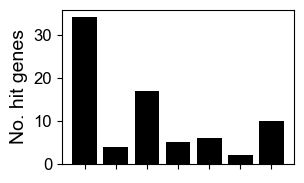

In [85]:
plt.figure(figsize=(3,2))

plt.bar(range(0,len(sorted(dist_types.keys(), reverse=True))), [dist_types[x] for x in sorted(dist_types.keys(), reverse=True)], color='k')
plt.ylabel('No. hit genes', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks([0,1,2,3,4,5,6], ['','','','','','',''])

plt.savefig('./figures/upset_plot.svg', format='svg', dpi=300)

In [86]:
[dist_types[x] for x in sorted(dist_types.keys(), reverse=True)]

[34, 4, 17, 5, 6, 2, 10]

## Compare with multi-environment screens

In [87]:
all_condition_hit_list = ['C1_03280W', 'RSM22', 'MRPL3', 'C1_08920W', 'NUP188',
                          'C2_03560C', 'QCR8', 'ATP4', 'C2_07680W', 'RRP15',
                          'SPT23', 'MRPL33', 'C3_05800W', 'C3_06520C', 'MMM1',
                          'ASK1', 'FOL1', 'ILV3', 'ILV5', 'ATP17', 'RTT109', 'MET6']

In [88]:
background_condition_hits = sorted([x for x in all_background_hits if x in all_condition_hit_list])

In [89]:
for y in sorted([x for x in all_background_hits if x in all_condition_hit_list]):
    print(y)

ASK1
ATP17
ATP4
C1_08920W
C2_03560C
C2_07680W
FOL1
ILV3
ILV5
MET6
MMM1
MRPL33
NUP188
QCR8
RSM22
RTT109
SPT23


## MRPL33 for the different backgrounds

In [90]:
for condition in ['log2fc_WT_median', 'log2fc_ARB_median', 'log2fc_ERB_median']:
    std_col_name = condition + '_std'
    col_start= condition.strip('_median')
    print(col_start, std_col_name)
    
    
    screen_clin_counts[std_col_name] = screen_clin_counts[[(col_start+'_1'),(col_start+'_2'),(col_start+'_3')]].std(axis=1)


log2fc_WT log2fc_WT_median_std
log2fc_ARB log2fc_ARB_median_std
log2fc_ERB log2fc_ERB_median_std


In [91]:
screen_clin_counts[screen_clin_counts['alias']== 'MRPL33'][['Gene', 'alias', 'SgRNA', 'Barcode', 
                                                        'log2fc_WT_median', 'log2fc_WT_median_std',
                                                        'log2fc_ARB_median', 'log2fc_ARB_median_std', 
                                                        'log2fc_ERB_median', 'log2fc_ERB_median_std']]

,Gene,alias,SgRNA,Barcode,log2fc_WT_median,log2fc_WT_median_std,log2fc_ARB_median,log2fc_ARB_median_std,log2fc_ERB_median,log2fc_ERB_median_std
218,C3_01080W,MRPL33,221,CGAAAGCTCAACGTTAAGGA,NaN,NaN,-3.301681,0.602295,-4.485773,0.921865
219,C3_01080W,MRPL33,222,CAACGTTAAGGAAGGAAGGA,-6.398524,1.130931,-6.106397,0.787555,-6.840222,0.744354
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,-5.297997,0.071668,-4.314457,0.505114,-4.687407,0.647876
221,C3_01080W,MRPL33,224,GGTTTGCAAAAACACATTTA,-4.977214,0.393986,-3.164096,0.633312,-3.277745,0.261664


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

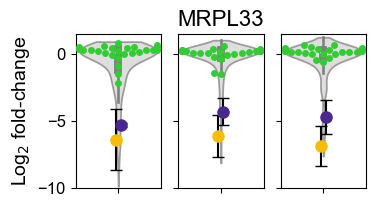

In [92]:

fig, axes = plt.subplots(1,3, sharey=True, figsize=(3.75,2))
sns.swarmplot(screen_clin_counts[is_control]['log2fc_WT_median'], zorder=8, color='limegreen', ax=axes[0])
sns.violinplot(screen_clin_counts[is_test]['log2fc_WT_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[0])


axes[0].errorbar(-0.025, screen_clin_counts.at[219,'log2fc_WT_median'],
             yerr=screen_clin_counts.at[219,'log2fc_WT_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[0].errorbar(0.025, screen_clin_counts.at[220,'log2fc_WT_median'],
             yerr=screen_clin_counts.at[220,'log2fc_WT_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

axes[0].set_xticks(ticks=[0], labels=[''], fontsize=14)
axes[0].set_ylabel('Log$_{2}$ fold-change', fontsize=14)

axes[0].tick_params(labelsize=12)
axes[0].set_ylim(-10,1.5)

##################

sns.swarmplot(screen_clin_counts[is_control]['log2fc_ARB_median'], zorder=8, color='limegreen', ax=axes[1])
sns.violinplot(screen_clin_counts[is_test]['log2fc_ARB_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[1])


axes[1].errorbar(-0.025, screen_clin_counts.at[219,'log2fc_ARB_median'],
             yerr=screen_clin_counts.at[219,'log2fc_ARB_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[1].errorbar(0.025, screen_clin_counts.at[220,'log2fc_ARB_median'],
             yerr=screen_clin_counts.at[220,'log2fc_ARB_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[1].set_xticks(ticks=[0], labels=[''], fontsize=14)

axes[1].set_title('MRPL33', fontsize=16)

##################

sns.swarmplot(screen_clin_counts[is_control]['log2fc_ERB_median'], zorder=8, color='limegreen', ax=axes[2])
sns.violinplot(screen_clin_counts[is_test]['log2fc_ERB_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[2])


axes[2].errorbar(-0.025, screen_clin_counts.at[219,'log2fc_ERB_median'],
             yerr=screen_clin_counts.at[219,'log2fc_ERB_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[2].errorbar(0.025, screen_clin_counts.at[220,'log2fc_ERB_median'],
             yerr=screen_clin_counts.at[220,'log2fc_ERB_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

axes[2].set_xticks(ticks=[0], labels=[''], fontsize=14)

plt.savefig('./figures/MRPL33_backgrounds_screen.svg', format='svg', dpi=300)

In [93]:
screen_clin_counts[screen_clin_counts['alias']== 'ASK1'][['Gene', 'alias', 'SgRNA', 'Barcode', 
                                                        'log2fc_WT_median', 'log2fc_WT_median_std',
                                                        'log2fc_ARB_median', 'log2fc_ARB_median_std', 
                                                        'log2fc_ERB_median', 'log2fc_ERB_median_std']]

,Gene,alias,SgRNA,Barcode,log2fc_WT_median,log2fc_WT_median_std,log2fc_ARB_median,log2fc_ARB_median_std,log2fc_ERB_median,log2fc_ERB_median_std
270,C4_01150W,ASK1,273,GTGTGTTTAAGGGATGCTGG,-1.543241,0.084909,-0.080793,0.268221,-1.419658,0.657093
271,C4_01150W,ASK1,274,TGGTGGTAAATGGTTAGTGG,-7.493614,0.706526,-3.948196,0.141749,-3.654829,0.052034
272,C4_01150W,ASK1,275,AAATGGTTAGTGGTGGTAAG,-7.176132,0.970908,-1.112300,0.087001,-5.332150,0.429837
273,C4_01150W,ASK1,276,TTAGTGGTGGTAAGTGGAGG,NaN,NaN,-3.759822,0.640815,-0.550807,0.222842


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

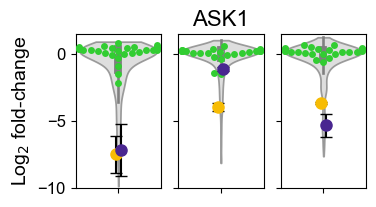

In [94]:
fig, axes = plt.subplots(1,3, sharey=True, figsize=(3.75,2))
sns.swarmplot(screen_clin_counts[is_control]['log2fc_WT_median'], zorder=8, color='limegreen', ax=axes[0])
sns.violinplot(screen_clin_counts[is_test]['log2fc_WT_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[0])


axes[0].errorbar(-0.025, screen_clin_counts.at[271,'log2fc_WT_median'],
             yerr=screen_clin_counts.at[271,'log2fc_WT_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[0].errorbar(0.025, screen_clin_counts.at[272,'log2fc_WT_median'],
             yerr=screen_clin_counts.at[272,'log2fc_WT_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

axes[0].set_xticks(ticks=[0], labels=[''], fontsize=14)
axes[0].set_ylabel('Log$_{2}$ fold-change', fontsize=14)

axes[0].tick_params(labelsize=12)
axes[0].set_ylim(-10,1.5)

##################

sns.swarmplot(screen_clin_counts[is_control]['log2fc_ARB_median'], zorder=8, color='limegreen', ax=axes[1])
sns.violinplot(screen_clin_counts[is_test]['log2fc_ARB_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[1])


axes[1].errorbar(-0.025, screen_clin_counts.at[271,'log2fc_ARB_median'],
             yerr=screen_clin_counts.at[271,'log2fc_ARB_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[1].errorbar(0.025, screen_clin_counts.at[272,'log2fc_ARB_median'],
             yerr=screen_clin_counts.at[272,'log2fc_ARB_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[1].set_xticks(ticks=[0], labels=[''], fontsize=14)

axes[1].set_title('ASK1', fontsize=16)

##################

sns.swarmplot(screen_clin_counts[is_control]['log2fc_ERB_median'], zorder=8, color='limegreen', ax=axes[2])
sns.violinplot(screen_clin_counts[is_test]['log2fc_ERB_median'], color='lightgrey', cut=0, alpha=0.75, ax=axes[2])


axes[2].errorbar(-0.025, screen_clin_counts.at[271,'log2fc_ERB_median'],
             yerr=screen_clin_counts.at[271,'log2fc_ERB_median_std']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
axes[2].errorbar(0.025, screen_clin_counts.at[272,'log2fc_ERB_median'],
             yerr=screen_clin_counts.at[272,'log2fc_ERB_median_std']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

axes[2].set_xticks(ticks=[0], labels=[''], fontsize=14)

plt.savefig('./figures/ASK1_backgrounds_screen.svg', format='svg', dpi=300)

### With Caspofungin

In [95]:
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_ATC_CASP_3,log2fc_WT_median,log2fc_WT_ATC_median,log2fc_ARB_median,log2fc_ARB_ATC_median,log2fc_ERB_median,log2fc_ERB_ATC_median,log2fc_WT_median_std,log2fc_ARB_median_std,log2fc_ERB_median_std
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,-0.270770,0.765472,0.192991,0.516476,0.200803,0.319649,0.063506,0.100297,0.515450,0.184525
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.038225,0.432387,0.099135,0.328640,0.021868,0.389088,0.162324,0.061185,0.078476,0.121524
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,0.074710,NaN,NaN,NaN,NaN,-0.523482,-0.409936,NaN,NaN,0.859991
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.643179,0.183954,-0.285412,-0.093210,-0.150349,-0.038559,-0.523790,0.183156,0.262222,0.178697
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.098619,0.166958,-0.100171,0.390679,-0.418710,0.847623,0.139862,0.182229,0.339025,0.294876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,-0.056160,0.429547,-0.013540,0.267046,0.067336,0.391986,0.129863,0.038183,0.043045,0.061999
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.506592,0.541622,0.290474,0.391936,0.315487,0.269115,0.111944,0.042615,0.082605,0.239311
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.735616,-0.005394,0.005427,0.053546,0.056689,0.296331,0.451145,0.042096,0.085244,0.159341
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.660066,-0.893084,-0.243982,-0.333870,0.128103,0.449891,0.455935,0.220738,0.159511,0.087841


In [96]:
backgrounds = ['WT', 'ARB', 'ERB']
inducer = ['_CASP', '_ATC_CASP']
# list of drugs, reps and ATC status

for background in backgrounds:
    for induc in inducer:
        # loop through columns
        
        col_name_base = 'log2fc_'+background+induc
        print(col_name_base)
        # base name of columns to compute the median 

        screen_clin_counts[col_name_base+'_median'] = screen_clin_counts[[(col_name_base+'_1'), (col_name_base+'_2'), (col_name_base+'_3')]].median(axis=1)
        print(col_name_base+'_median')
        # compute median using pandas method, axis=1 specifies median is to be computed across columns

log2fc_WT_CASP
log2fc_WT_CASP_median
log2fc_WT_ATC_CASP
log2fc_WT_ATC_CASP_median
log2fc_ARB_CASP
log2fc_ARB_CASP_median
log2fc_ARB_ATC_CASP
log2fc_ARB_ATC_CASP_median
log2fc_ERB_CASP
log2fc_ERB_CASP_median
log2fc_ERB_ATC_CASP
log2fc_ERB_ATC_CASP_median


In [97]:
screen_clin_counts['log2fc_WT_CASP_median']

0      0.923338
1      0.281380
2           NaN
3      1.116987
4     -1.687310
         ...   
548    0.073873
549    0.185708
550    0.034340
551   -0.805962
552   -1.746384
Name: log2fc_WT_CASP_median, Length: 553, dtype: float64

In [98]:
for background in backgrounds:
    for induc in inducer:
        col_name_base = 'log2fc_'+background+induc
        median_col_name = col_name_base+'_median'
        
        n_nans = screen_clin_counts[[(col_name_base+'_1'),(col_name_base+'_2'),(col_name_base+'_3')]].isnull().sum(axis=1)
        above_0_nan = list(n_nans[n_nans>0].index)
        print(median_col_name, len(above_0_nan))
        
        for row in above_0_nan:
            screen_clin_counts.at[row,median_col_name]=np.nan

log2fc_WT_CASP_median 80
log2fc_WT_ATC_CASP_median 89
log2fc_ARB_CASP_median 36
log2fc_ARB_ATC_CASP_median 33
log2fc_ERB_CASP_median 32
log2fc_ERB_ATC_CASP_median 65


In [99]:
[len(screen_clin_counts[is_control|is_test]['log2fc_WT_CASP_median'].dropna()), 
 len(screen_clin_counts[is_control|is_test]['log2fc_ARB_CASP_median'].dropna()), 
 len(screen_clin_counts[is_control|is_test]['log2fc_ERB_CASP_median'].dropna())]

[471, 515, 519]

### WT CASP

In [100]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

In [101]:
WT_CASP_on_mean, WT_CASP_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_WT_CASP_median'].dropna())
WT_CASP_on_mean, WT_CASP_on_scale

(0.07435779874734089, 0.5305119917928417)

-1.4637917426417149 0.0018695782020220297 83 0.18778280542986425 0.009956067051731772
-1.4620217405345306 0.0018895711838502044 83 0.18778280542986425 0.010062535701949281
-1.4602517384273455 0.0019097582805871016 83 0.18778280542986425 0.010170038072524083
-1.4584817363201612 0.001930141150029168 83 0.18778280542986425 0.010278582991721593
-1.456711734212976 0.0019507214616704346 83 0.18778280542986425 0.010388179350100387
-1.4549417321057918 0.0019715008967597786 83 0.18778280542986425 0.010498836100817133
-1.4531717299986067 0.0019924811483583893 83 0.18778280542986425 0.010610562259932628
-1.4514017278914224 0.0020136639213971103 83 0.18778280542986425 0.010723366906717142
-1.4496317257842373 0.0020350509327339387 83 0.18778280542986425 0.010837259183956638
-1.447861723677053 0.0020566439112114027 84 0.19004524886877827 0.010821864389945715
-1.4460917215698688 0.0020784445977141118 84 0.19004524886877827 0.010936577526067113
-1.4443217194626836 0.0021004547452262066 84 0.1900452488

Text(0, 0.5, 'FDR')

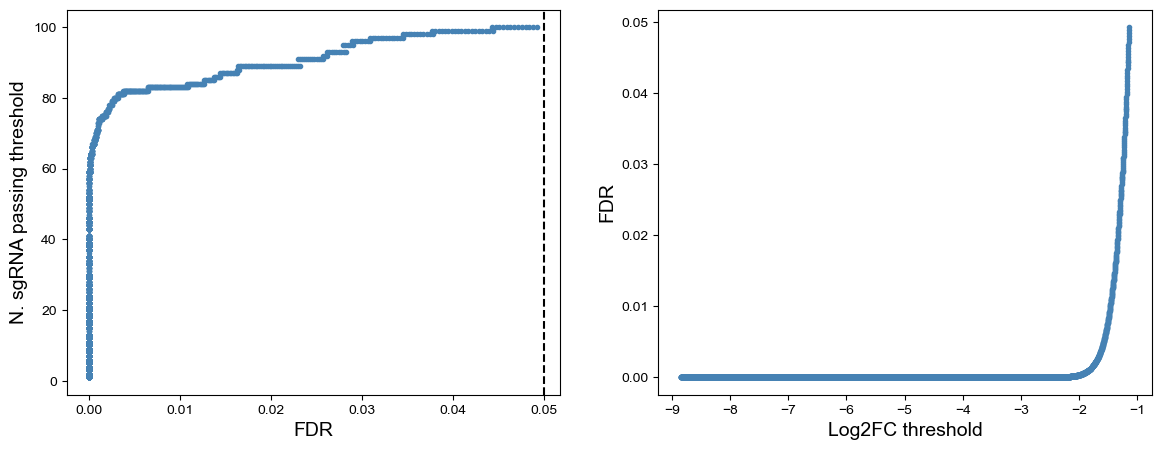

In [102]:
target_col = 'log2fc_WT_CASP_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=WT_CASP_on_mean, scale=WT_CASP_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.0099:
        print(val, FPR, positives, PR, FDR) 

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [103]:
threshold_WT_CASP_on = -1.1381113549197375

(array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 ]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.25, '0.25'),
  Text(0, 0.5, '0.50'),
  Text(0, 0.75, '0.75'),
  Text(0, 1.0, '1.00'),
  Text(0, 1.25, '1.25'),
  Text(0, 1.5, '1.50')])

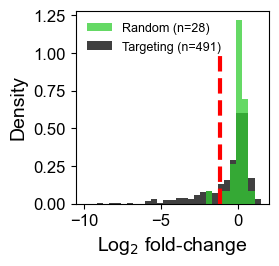

In [104]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_WT_CASP_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_WT_CASP_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=28)', 'Targeting (n=491)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_WT_CASP_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



In [105]:
stats.ttest_rel(a=screen_clin_counts[['log2fc_WT_1', 'log2fc_WT_2', 'log2fc_WT_3']], b=screen_clin_counts[['log2fc_WT_CASP_1', 'log2fc_WT_CASP_2', 'log2fc_WT_CASP_3']], nan_policy='omit')

TtestResult(statistic=array([-4.4646805 , -5.0459416 , -5.40996126]), pvalue=array([1.00102407e-05, 6.39205325e-07, 9.99329067e-08]), df=array([479., 485., 477.]))

In [106]:
for col in ['log2fc_WT_1', 'log2fc_WT_2', 'log2fc_WT_3', 'log2fc_WT_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-wt_on_mean)/wt_on_scale

for col in ['log2fc_WT_CASP_1', 'log2fc_WT_CASP_2', 'log2fc_WT_CASP_3', 'log2fc_WT_CASP_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-WT_CASP_on_mean)/WT_CASP_on_scale

In [107]:
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_CASP_median,log2fc_ERB_ATC_CASP_median,log2fc_WT_1_z_score,log2fc_WT_2_z_score,log2fc_WT_3_z_score,log2fc_WT_median_z_score,log2fc_WT_CASP_1_z_score,log2fc_WT_CASP_2_z_score,log2fc_WT_CASP_3_z_score,log2fc_WT_CASP_median_z_score
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,-0.396387,-0.062987,1.198780,0.999535,0.879519,0.999535,1.586720,1.600303,2.288525,1.600303
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,-0.029998,0.241343,0.302039,0.479777,0.463987,0.463987,0.798471,0.390231,0.272385,0.390231
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-1.308382,0.074710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,0.498495,-0.539243,0.459329,0.064547,-0.116579,0.064547,1.965327,0.831322,2.267889,1.965327
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.029793,-0.035517,-0.458538,0.037220,0.059908,0.037220,-4.321087,-3.320693,-2.725283,-3.320693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.118377,0.052491,0.457092,0.564572,0.459421,0.459421,-0.032466,-0.000913,0.445690,-0.000913
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,-0.829913,0.501640,0.639620,0.714324,0.577482,0.639620,-0.197314,0.404298,0.209892,0.209892
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.594143,0.735616,-0.194482,-0.327626,-0.239894,-0.239894,-0.038526,-0.123930,-0.075432,-0.075432
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.213023,0.660066,-1.220713,-1.921848,-1.667157,-1.667157,-1.041823,-1.659379,-2.424889,-1.659379


In [108]:
screen_clin_counts['log2fc_WT_CASP_effect'] = screen_clin_counts['log2fc_WT_CASP_median_z_score'] - screen_clin_counts['log2fc_WT_median_z_score']

In [109]:
YPD_cols = ['log2fc_WT_1_z_score', 'log2fc_WT_2_z_score', 'log2fc_WT_3_z_score']
CASP_cols = ['log2fc_WT_CASP_1_z_score', 'log2fc_WT_CASP_2_z_score', 'log2fc_WT_CASP_3_z_score']

def ttest_row(row):
    return stats.ttest_ind(row[YPD_cols].astype(np.float64), row[CASP_cols].astype(np.float64), equal_var=False)

In [110]:
results_WT_CASP_effect = screen_clin_counts.apply(ttest_row, axis=1)
screen_clin_counts['WT_CASP_effect_t_stat'] = [r.statistic for r in results_WT_CASP_effect]
screen_clin_counts['WT_CASP_effect_p_value'] = [r.pvalue for r in results_WT_CASP_effect]

WT_CASP_p_value_corr = stats.false_discovery_control(screen_clin_counts['WT_CASP_effect_p_value'].dropna(), method='bh')

# convert to np.log10 and apply Bonferonni

In [111]:
corr_pval_index_WT_CASP = list((screen_clin_counts['WT_CASP_effect_p_value'].dropna().index))

corr_pval_col_dict = {}
for x in range(0, len(corr_pval_index_WT_CASP)):
    corr_pval_col_dict[corr_pval_index_WT_CASP[x]] = WT_CASP_p_value_corr[x]


screen_clin_counts['WT_CASP_effect_p_value_corr'] = pd.Series(corr_pval_col_dict)
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_WT_3_z_score,log2fc_WT_median_z_score,log2fc_WT_CASP_1_z_score,log2fc_WT_CASP_2_z_score,log2fc_WT_CASP_3_z_score,log2fc_WT_CASP_median_z_score,log2fc_WT_CASP_effect,WT_CASP_effect_t_stat,WT_CASP_effect_p_value,WT_CASP_effect_p_value_corr
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.879519,0.999535,1.586720,1.600303,2.288525,1.600303,0.600768,-3.200662,0.059164,0.144250
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.463987,0.463987,0.798471,0.390231,0.272385,0.390231,-0.073756,-0.424095,0.705280,0.788646
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.116579,0.064547,1.965327,0.831322,2.267889,1.965327,1.900780,-3.309102,0.056117,0.138970
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.059908,0.037220,-4.321087,-3.320693,-2.725283,-3.320693,-3.357914,6.732837,0.011357,0.055544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.459421,0.459421,-0.032466,-0.000913,0.445690,-0.000913,-0.460335,2.248937,0.141309,0.254142
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.577482,0.639620,-0.197314,0.404298,0.209892,0.209892,-0.429728,2.779774,0.097915,0.200849
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,-0.239894,-0.239894,-0.038526,-0.123930,-0.075432,-0.075432,0.164463,-3.777833,0.026349,0.087159
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,-1.667157,-1.667157,-1.041823,-1.659379,-2.424889,-1.659379,0.007778,0.234640,0.829676,0.878187


In [112]:
(-1.1381113549197375-WT_CASP_on_mean)/WT_CASP_on_scale

-2.285469833715903

(-8.0, 8.0)

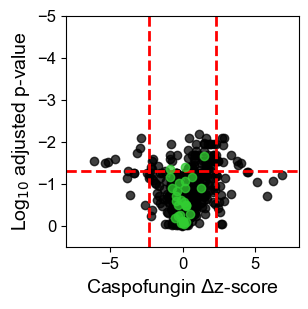

In [113]:
plt.figure(figsize=(3,3))

plt.scatter(screen_clin_counts[is_control]['log2fc_WT_CASP_effect'], np.log10(screen_clin_counts[is_control]['WT_CASP_effect_p_value_corr']), color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_clin_counts[is_test]['log2fc_WT_CASP_effect'], np.log10(screen_clin_counts[is_test]['WT_CASP_effect_p_value_corr']), color='k', alpha=0.75)


plt.ylim(0.5,-5)

plt.axhline(np.log10(0.05), linestyle='--', color='red', lw=2)
plt.axvline(-2.285469833715903, linestyle='--', color='red', lw=2)
plt.axvline(2.285469833715903, linestyle='--', color='red', lw=2)

plt.xlabel(r'Caspofungin $\Delta$z-score', fontsize=14)
plt.xticks(fontsize=12)

plt.ylabel('Log$_{10}$ adjusted p-value', fontsize=14)
plt.yticks(fontsize=12)

plt.xlim(-8,8)



In [114]:
(threshold_wt_on-wt_on_mean)/wt_on_scale

-2.2604386448214244

In [115]:
(threshold_WT_CASP_on-WT_CASP_on_mean)/WT_CASP_on_scale

-2.285469833715903

In [116]:
np.mean([(threshold_wt_on-wt_on_mean)/wt_on_scale, (threshold_WT_CASP_on-WT_CASP_on_mean)/WT_CASP_on_scale])

-2.272954239268664

In [117]:
np.mean([(-1.6407009363474483-wt_on_mean)/wt_on_scale, (-1.4637917426417149-WT_CASP_on_mean)/WT_CASP_on_scale])

-2.884285943514354

In [118]:
screen_clin_counts[(screen_clin_counts['log2fc_WT_CASP_effect']<-2.272954239268664)&(screen_clin_counts['WT_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA',                                                                                                                                                                                   'log2fc_WT_median_z_score', 'log2fc_WT_CASP_median_z_score', 'log2fc_WT_CASP_effect', 'WT_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_WT_median_z_score,log2fc_WT_CASP_median_z_score,log2fc_WT_CASP_effect,WT_CASP_effect_p_value_corr
7,C1_00400W,SVF1,8,-1.110722,-4.048453,-2.937731,0.013973
24,C1_01950C,C1_01950C,25,-3.879613,-9.972218,-6.092605,0.028887
39,C1_02620C,HOM6,40,-0.704867,-3.588325,-2.883458,0.007952
46,C1_02960C,C1_02960C,47,-0.998756,-5.651963,-4.653207,0.026442
169,C2_04590C,QCR8,170,-3.379301,-8.695927,-5.316626,0.031592
228,C3_02370C,ALR1,231,-1.731486,-4.885108,-3.153622,0.018840
372,C7_00730W,MET28,375,-0.990918,-6.133515,-5.142597,0.030156


In [119]:
screen_clin_counts[(screen_clin_counts['log2fc_WT_CASP_effect']>2.272954239268664)&(screen_clin_counts['WT_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA', 'log2fc_WT_median_z_score', 'log2fc_WT_CASP_median_z_score', 'log2fc_WT_CASP_effect' , 'WT_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_WT_median_z_score,log2fc_WT_CASP_median_z_score,log2fc_WT_CASP_effect,WT_CASP_effect_p_value_corr
13,C1_00510W,C1_00510W,14,-3.850264,-1.093022,2.757242,0.030156
14,C1_00510W,C1_00510W,15,-4.835457,-2.390253,2.445204,0.028507
51,C1_03280W,C1_03280W,52,-3.216550,-0.384293,2.832256,0.007952
84,C1_07600W,ATP7,85,-3.898327,-1.203673,2.694654,0.007952
165,C2_03560C,C2_03560C,166,-6.930333,-4.494755,2.435578,0.028507
214,C2_10280C,SPT23,217,-3.897766,0.143615,4.041381,0.031592
220,C3_01080W,MRPL33,223,-8.749546,-5.424190,3.325357,0.020329
371,C7_00730W,MET28,374,-1.966642,0.830011,2.796653,0.012088
402,C7_03120W,TIM54,405,-2.089590,0.188649,2.278239,0.021131
426,CR_00680W,BUD22,429,-8.571835,-4.846243,3.725592,0.028333


### Changes in ERB

In [120]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

In [121]:
ERB_CASP_on_mean, ERB_CASP_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_ERB_CASP_median'].dropna())
ERB_CASP_on_mean, ERB_CASP_on_scale

(0.14567610563222957, 0.4596844809705835)

-1.2113679464884104 0.0015779979183258364 78 0.15885947046843177 0.009933294588435714
-1.2100526718451006 0.0015926824398692667 78 0.15885947046843177 0.01002573176892064
-1.2087373972017907 0.001607491402210013 78 0.15885947046843177 0.010118952288270724
-1.207422122558481 0.0016224257376301042 78 0.15885947046843177 0.01021296201508181
-1.206106847915171 0.0016374863842428056 78 0.15885947046843177 0.010307766854656635
-1.2047915732718613 0.0016526742860188182 78 0.15885947046843177 0.010403372749169741
-1.2034762986285514 0.0016679903928125516 78 0.15885947046843177 0.010499785677832857
-1.2021610239852416 0.0016834356603883304 78 0.15885947046843177 0.010597011657059875
-1.2008457493419318 0.0016990110504467317 78 0.15885947046843177 0.010695056740632631
-1.199530474698622 0.0017147175306508776 78 0.15885947046843177 0.010793927019866421
-1.1982152000553121 0.0017305560746527916 78 0.15885947046843177 0.010893628623775907
-1.1968999254120023 0.0017465276621197407 78 0.1588594704684

Text(0, 0.5, 'FDR')

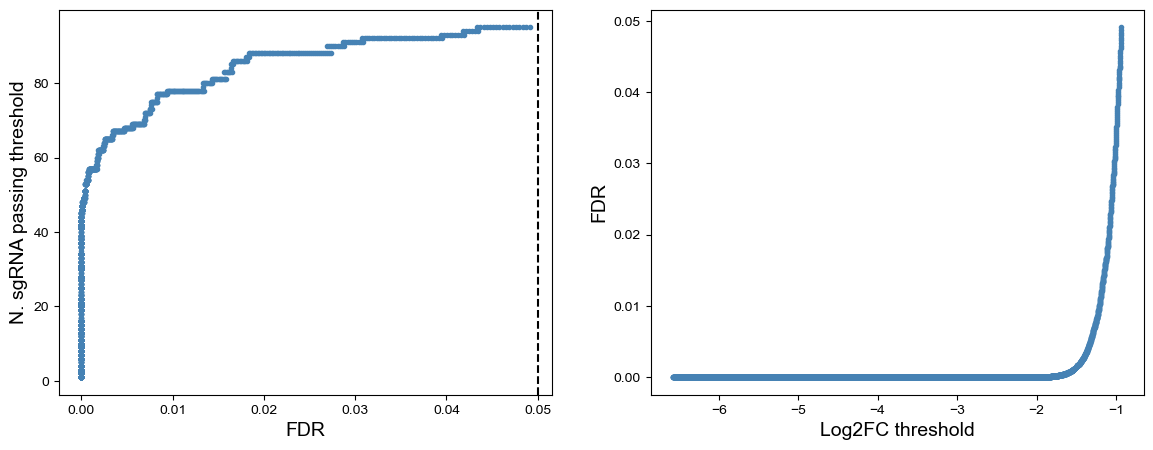

In [122]:
target_col = 'log2fc_ERB_CASP_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=ERB_CASP_on_mean, scale=ERB_CASP_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.0099:
        print(val, FPR, positives, PR, FDR) 

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [123]:
threshold_ERB_CASP_on = -0.9325297221067137

(array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 ]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.25, '0.25'),
  Text(0, 0.5, '0.50'),
  Text(0, 0.75, '0.75'),
  Text(0, 1.0, '1.00'),
  Text(0, 1.25, '1.25'),
  Text(0, 1.5, '1.50')])

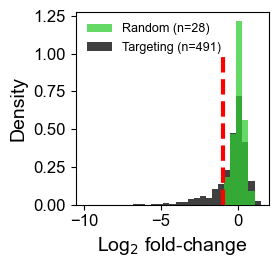

In [124]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_ERB_CASP_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_ERB_CASP_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=28)', 'Targeting (n=491)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_ERB_CASP_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



In [125]:
for col in ['log2fc_ERB_1', 'log2fc_ERB_2', 'log2fc_ERB_3', 'log2fc_ERB_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-wt_on_mean)/wt_on_scale

for col in ['log2fc_ERB_CASP_1', 'log2fc_ERB_CASP_2', 'log2fc_ERB_CASP_3', 'log2fc_ERB_CASP_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-ERB_CASP_on_mean)/ERB_CASP_on_scale

In [126]:
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,WT_CASP_effect_p_value,WT_CASP_effect_p_value_corr,log2fc_ERB_1_z_score,log2fc_ERB_2_z_score,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.059164,0.144250,0.182592,0.282723,0.739163,0.282723,-1.179208,-1.307199,1.189886,-1.179208
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.705280,0.788646,0.067833,0.394370,0.417013,0.394370,-0.382163,-0.584491,0.513430,-0.382163
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,NaN,NaN,0.315442,-1.072896,-2.450004,-1.072896,-0.968777,-13.274848,-3.163166,-3.163166
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,0.056117,0.138970,-0.293218,-0.701672,-0.147409,-0.293218,0.907641,-2.600373,0.767525,0.767525
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.011357,0.055544,0.661741,1.131620,1.609956,1.131620,-1.168746,-0.318262,-0.381715,-0.381715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.141309,0.254142,0.399029,0.370503,0.555647,0.399029,0.264400,-0.059387,-0.113494,-0.059387
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.097915,0.200849,0.722972,-0.027859,0.201471,0.201471,-2.236776,-2.122301,-0.854706,-2.122301
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.026349,0.087159,0.241663,0.245231,0.687178,0.245231,1.223941,0.825507,0.975598,0.975598
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.829676,0.878187,0.492131,0.412950,0.687356,0.492131,0.272778,0.146507,-0.478525,0.146507


In [127]:
screen_clin_counts['log2fc_ERB_CASP_effect'] = screen_clin_counts['log2fc_ERB_CASP_median_z_score'] - screen_clin_counts['log2fc_ERB_median_z_score']

In [128]:
YPD_cols = ['log2fc_ERB_1_z_score', 'log2fc_ERB_2_z_score', 'log2fc_ERB_3_z_score']
CASP_cols = ['log2fc_ERB_CASP_1_z_score', 'log2fc_ERB_CASP_2_z_score', 'log2fc_ERB_CASP_3_z_score']

def ttest_row(row):
    return stats.ttest_ind(row[YPD_cols].astype(np.float64), row[CASP_cols].astype(np.float64), equal_var=False)

In [129]:
results_ERB_CASP_effect = screen_clin_counts.apply(ttest_row, axis=1)
screen_clin_counts['ERB_CASP_effect_t_stat'] = [r.statistic for r in results_ERB_CASP_effect]
screen_clin_counts['ERB_CASP_effect_p_value'] = [r.pvalue for r in results_ERB_CASP_effect]

ERB_CASP_p_value_corr = stats.false_discovery_control(screen_clin_counts['ERB_CASP_effect_p_value'].dropna(), method='bh')

# convert to np.log10 and apply Bonferonni

In [130]:
corr_pval_index_ERB_CASP = list((screen_clin_counts['ERB_CASP_effect_p_value'].dropna().index))

corr_pval_col_dict = {}
for x in range(0, len(corr_pval_index_ERB_CASP)):
    corr_pval_col_dict[corr_pval_index_ERB_CASP[x]] = ERB_CASP_p_value_corr[x]


screen_clin_counts['ERB_CASP_effect_p_value_corr'] = pd.Series(corr_pval_col_dict)
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.739163,0.282723,-1.179208,-1.307199,1.189886,-1.179208,-1.461931,1.004727,0.413360,0.604994
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.417013,0.394370,-0.382163,-0.584491,0.513430,-0.382163,-0.776533,1.248623,0.318151,0.526937
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-2.450004,-1.072896,-0.968777,-13.274848,-3.163166,-3.163166,-2.090270,1.222146,0.337424,0.549369
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.147409,-0.293218,0.907641,-2.600373,0.767525,0.767525,1.060743,-0.062456,0.955677,0.984202
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,1.609956,1.131620,-1.168746,-0.318262,-0.381715,-0.381715,-1.513335,4.541261,0.010487,0.095855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.555647,0.399029,0.264400,-0.059387,-0.113494,-0.059387,-0.458417,3.132535,0.054377,0.208311
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.201471,0.201471,-2.236776,-2.122301,-0.854706,-2.122301,-2.323772,4.111058,0.026978,0.154454
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.687178,0.245231,1.223941,0.825507,0.975598,0.975598,0.730367,-3.280393,0.033041,0.166698
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.687356,0.492131,0.272778,0.146507,-0.478525,0.146507,-0.345624,2.236548,0.129581,0.332571


(-8.0, 8.0)

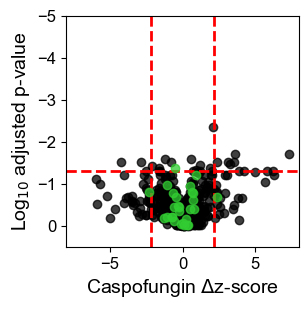

In [131]:
plt.figure(figsize=(3,3))

plt.scatter(screen_clin_counts[is_control]['log2fc_ERB_CASP_effect'], np.log10(screen_clin_counts[is_control]['ERB_CASP_effect_p_value_corr']), color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_clin_counts[is_test]['log2fc_ERB_CASP_effect'], np.log10(screen_clin_counts[is_test]['ERB_CASP_effect_p_value_corr']), color='k', alpha=0.75)


plt.ylim(0.5,-5)

plt.axhline(np.log10(0.05), linestyle='--', color='red', lw=2)
plt.axvline(-2.20, linestyle='--', color='red', lw=2)
plt.axvline(2.20, linestyle='--', color='red', lw=2)

plt.xlabel(r'Caspofungin $\Delta$z-score', fontsize=14)
plt.xticks(fontsize=12)

plt.ylabel('Log$_{10}$ adjusted p-value', fontsize=14)
plt.yticks(fontsize=12)

plt.xlim(-8,8)



In [132]:
(threshold_ERB_on-ERB_CASP_on_mean)/ERB_on_scale

-2.0546501988255734

In [133]:
(threshold_ERB_CASP_on-ERB_CASP_on_mean)/ERB_CASP_on_scale

-2.345534540262064

In [134]:
np.mean([(threshold_ERB_on-ERB_CASP_on_mean)/ERB_on_scale, (threshold_ERB_CASP_on-ERB_CASP_on_mean)/ERB_CASP_on_scale])

-2.200092369543819

In [135]:
screen_clin_counts[(screen_clin_counts['log2fc_ERB_CASP_effect']<-2.20)&(screen_clin_counts['ERB_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA',                                                                                                                                                                                   'log2fc_ERB_median_z_score', 'log2fc_ERB_CASP_median_z_score', 'log2fc_ERB_CASP_effect', 'ERB_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_ERB_median_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_p_value_corr
97,C1_09030C,COX5,98,-3.185231,-14.642074,-11.456843,0.020077
152,C2_01200C,REG1,153,-0.631591,-4.861161,-4.229570,0.029696
372,C7_00730W,MET28,375,-0.439871,-3.316690,-2.876819,0.029696
477,CR_03950W,CR_03950W,480,-0.053184,-2.580351,-2.527167,0.049711


In [136]:
screen_clin_counts[(screen_clin_counts['log2fc_ERB_CASP_effect']>2.20)&(screen_clin_counts['ERB_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA', 'log2fc_ERB_median_z_score', 'log2fc_ERB_CASP_median_z_score', 'log2fc_ERB_CASP_effect' , 'ERB_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_ERB_median_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_p_value_corr
108,C1_10960W,C1_10960W,109,-7.293788,-4.046655,3.247133,0.034731
124,C1_12360C,RIB3,125,0.736090,3.884863,3.148773,0.029696
215,C2_10280C,SPT23,218,-0.713088,1.628627,2.341714,0.029696
217,C2_10280C,SPT23,220,-8.833079,-1.507946,7.325132,0.020077
221,C3_01080W,MRPL33,224,-5.501306,-1.960841,3.540465,0.029696
263,C4_00560C,MMM1,266,-6.631744,-2.434461,4.197283,0.049711
340,C6_00870C,ILV5,343,-1.400802,4.855610,6.256412,0.049711
445,CR_01620C,MET6,448,-10.620609,-6.746967,3.873642,0.049711
482,CR_04520W,MIM1,485,1.126965,4.723548,3.596583,0.020077


In [137]:
background_condition_hits

['ASK1',
 'ATP17',
 'ATP4',
 'C1_08920W',
 'C2_03560C',
 'C2_07680W',
 'FOL1',
 'ILV3',
 'ILV5',
 'MET6',
 'MMM1',
 'MRPL33',
 'NUP188',
 'QCR8',
 'RSM22',
 'RTT109',
 'SPT23']

In [138]:
core_essential_target = screen_clin_counts['alias'].isin(background_condition_hits)


In [139]:
gene_order = ['ASK1', 'ATP17', 'ATP4', 'FOL1', 'ILV3', 'ILV5', 'MET6', 'MMM1', 
              'MRPL33', 'QCR8', 'RSM22', 'RTT109', 'SPT23', 'C1_08920W', 'C2_03560C', 'C2_07680W']

In [140]:
w_significant_changes_WT = (screen_clin_counts['WT_CASP_effect_p_value_corr']<=0.05)
w_significant_changes_ERB = (screen_clin_counts['ERB_CASP_effect_p_value_corr']<=0.05)
w_antagonism_WT = screen_clin_counts['log2fc_WT_CASP_effect'] >=2.27
w_synergy_WT = screen_clin_counts['log2fc_WT_CASP_effect'] <=-2.27
w_antagonism_ERB = screen_clin_counts['log2fc_ERB_CASP_effect'] >=2.20
w_synergy_ERB = screen_clin_counts['log2fc_ERB_CASP_effect'] <=-2.20

In [141]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_antagonism_WT&w_significant_changes_ERB&w_antagonism_ERB]
# No significant antagonism in both strains

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr


In [142]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_synergy_WT&w_significant_changes_ERB&w_synergy_ERB]
# No significant synergy in both strains

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr


In [143]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_antagonism_WT&w_significant_changes_ERB&w_synergy_ERB]
# No sign epistasis -/+

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr


In [144]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_synergy_WT&w_significant_changes_ERB&w_antagonism_ERB]
# No sign epistasis +/-

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr


In [145]:
significant_synergy_WT = core_essential_target&w_significant_changes_WT&w_synergy_WT
screen_clin_counts[significant_synergy_WT]
# synergy, WT only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr
169,C2_04590C,QCR8,170,TCTCTCTCTCACTTTGGTGG,0,-,109.0,no,-78.0,78.0,...,-1.212478,-1.026372,-3.493258,-3.077592,-4.422389,-3.493258,-2.466886,6.40677,0.02071,0.140127


In [146]:
screen_clin_counts[core_essential_target&w_significant_changes_ERB&w_synergy_ERB]
# synergy, ERB only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr


In [147]:
significant_antagonism_WT = core_essential_target&w_significant_changes_WT&w_antagonism_WT
screen_clin_counts[significant_antagonism_WT]
# antagonism, WT only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr
165,C2_03560C,C2_03560C,166,AGGAAATTCGCCAGAACTCT,0,+,105.0,no,-79.0,79.0,...,-5.020672,-5.020672,-1.090710,-2.827948,-2.925390,-2.827948,2.192724,-4.513939,0.043941,0.192382
214,C2_10280C,SPT23,217,AAAGTGGAAAGTGGTGGAGG,0,-,150.0,no,11.0,11.0,...,-1.153066,-0.810034,1.644906,1.381900,0.459717,1.381900,2.191934,-5.317644,0.018864,0.131042
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,0,+,247.0,no,-171.0,171.0,...,-7.767815,-7.767815,-6.359534,-5.156353,-2.832497,-5.156353,2.611462,-2.884432,0.058314,0.215526


In [148]:
significant_antagonism_ERB = core_essential_target&w_significant_changes_ERB&w_antagonism_ERB
screen_clin_counts[significant_antagonism_ERB]
# antagonism, ERB only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_3_z_score,log2fc_ERB_median_z_score,log2fc_ERB_CASP_1_z_score,log2fc_ERB_CASP_2_z_score,log2fc_ERB_CASP_3_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_t_stat,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr
215,C2_10280C,SPT23,218,TGTGTGTAATAAGTGTGTGT,0,-,281.0,no,-120.0,120.0,...,-0.411166,-0.713088,1.753640,1.605294,1.628627,1.628627,2.341714,-18.936908,0.000656,0.029696
217,C2_10280C,SPT23,220,TTTGAGTAGGCGGGTGGTAG,0,-,245.0,no,-84.0,84.0,...,-8.833079,-8.833079,-1.340143,-1.507946,-2.227203,-1.507946,7.325132,-15.846245,0.000135,0.020077
221,C3_01080W,MRPL33,224,GGTTTGCAAAAACACATTTA,0,+,226.0,no,-150.0,150.0,...,-6.021911,-5.501306,-1.928156,-2.676908,-1.960841,-1.960841,3.540465,-9.817077,0.000604,0.029696
263,C4_00560C,MMM1,266,AGTGCCAGAGATTTCACAGT,0,+,88.0,no,-53.0,53.0,...,-6.690315,-6.631744,-2.434461,-1.495209,-2.466872,-2.434461,4.197283,-13.063478,0.002314,0.049711
340,C6_00870C,ILV5,343,AATCTGCGCTATTCCGCTAC,0,+,260.0,no,-208.0,208.0,...,-1.617387,-1.400802,4.935807,4.855610,3.237267,4.855610,6.256412,-8.576126,0.002389,0.049711
445,CR_01620C,MET6,448,ATTCCTAAACGAGGAGTGGG,0,-,214.0,no,-158.0,158.0,...,-9.752532,-10.620609,-6.746967,-6.488240,-6.975017,-6.746967,3.873642,-10.621192,0.002481,0.049711


In [149]:
all_significant_genes = screen_clin_counts[significant_synergy_WT|significant_antagonism_WT|significant_antagonism_ERB]['alias'].unique()
all_significant_genes

array(['C2_03560C', 'QCR8', 'SPT23', 'MRPL33', 'MMM1', 'ILV5', 'MET6'],
      dtype=object)

In [150]:
color_list = sns.color_palette('hls',len(all_significant_genes))

In [151]:
color_dict = {}
for x in range(0,len(all_significant_genes)):
    color_dict[all_significant_genes[x]] = color_list[x]

for x in background_condition_hits:
    if x not in list(color_dict.keys()):
        color_dict[x] = 'k'

color_dict

{'C2_03560C': (0.86, 0.3712, 0.33999999999999997),
 'QCR8': (0.86, 0.8169142857142857, 0.33999999999999997),
 'SPT23': (0.4573714285714283, 0.86, 0.33999999999999997),
 'MRPL33': (0.33999999999999997, 0.86, 0.6683428571428571),
 'MMM1': (0.33999999999999997, 0.6059428571428571, 0.86),
 'ILV5': (0.5197714285714281, 0.33999999999999997, 0.86),
 'MET6': (0.86, 0.33999999999999997, 0.7545142857142858),
 'ASK1': 'k',
 'ATP17': 'k',
 'ATP4': 'k',
 'C1_08920W': 'k',
 'C2_07680W': 'k',
 'FOL1': 'k',
 'ILV3': 'k',
 'NUP188': 'k',
 'RSM22': 'k',
 'RTT109': 'k'}

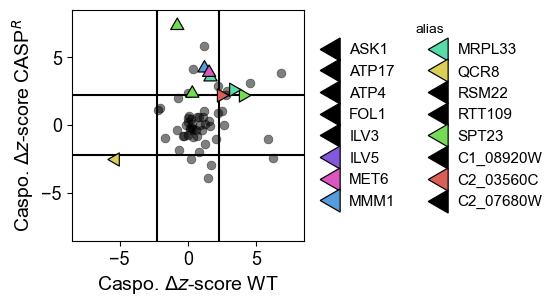

In [152]:
plt.figure(figsize=(3,3))


ax = sns.scatterplot(data=screen_clin_counts[core_essential_target&~significant_synergy_WT&~significant_antagonism_WT&~significant_antagonism_ERB], x='log2fc_WT_CASP_effect', y='log2fc_ERB_CASP_effect', 
                     zorder=6, s=40, color='k', edgecolor='k', marker='o', legend=False, alpha=0.5)

ax = sns.scatterplot(data=screen_clin_counts[core_essential_target&significant_synergy_WT], 
                     x='log2fc_WT_CASP_effect', y='log2fc_ERB_CASP_effect', 
                     hue='alias',zorder=9, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 90), legend=True, palette=color_dict)

ax = sns.scatterplot(data=screen_clin_counts[core_essential_target&significant_antagonism_WT], x='log2fc_WT_CASP_effect', y='log2fc_ERB_CASP_effect', 
                     hue='alias',zorder=8, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 270), legend=False, palette=color_dict)

ax = sns.scatterplot(data=screen_clin_counts[significant_antagonism_ERB], x='log2fc_WT_CASP_effect', y='log2fc_ERB_CASP_effect', 
                     hue='alias',zorder=7, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 0), legend=False, palette=color_dict)



#plt.scatter(screen_clin_counts[~core_essential_target&is_test]['log2fc_WT_CASP_effect'], screen_clin_counts[~core_essential_target&is_test]['log2fc_ERB_CASP_effect'], color='k', alpha=0.1,zorder=5)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncols=2, fontsize=11, markerscale=1.75, handletextpad=0.05, frameon=False)


plt.axvline(-2.27, color='k')
plt.axvline(2.27, color='k')

plt.axhline(-2.20, color='k')
plt.axhline(2.20, color='k')

plt.xlim(-8.5,8.5)
plt.xticks([-5,0,5], fontsize=13)
plt.ylim(-8.5,8.5)
plt.yticks([-5,0,5], fontsize=13)

plt.xlabel(r'Caspo. $\it{\Delta}z$-score WT', fontsize=14)
plt.ylabel(r'Caspo. $\it{\Delta}z$-score CASP$^{R}$', fontsize=14)

plt.savefig('./figures/casp_effect_core_essential_genes.svg', format='svg', dpi=300)

In [153]:
screen_clin_counts[screen_clin_counts['alias']=='MRPL33'][['Gene', 'alias', 'SgRNA', 'log2fc_ERB_median_z_score', 'log2fc_ERB_CASP_median_z_score', 
                                                     'log2fc_ERB_CASP_effect', 'ERB_CASP_effect_p_value', 'ERB_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_ERB_median_z_score,log2fc_ERB_CASP_median_z_score,log2fc_ERB_CASP_effect,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr
218,C3_01080W,MRPL33,221,-7.443620,-7.928790,-0.485170,0.412256,0.604994
219,C3_01080W,MRPL33,222,-11.229194,-7.356584,3.872611,0.595489,0.736593
220,C3_01080W,MRPL33,223,-7.767815,-5.156353,2.611462,0.058314,0.215526
221,C3_01080W,MRPL33,224,-5.501306,-1.960841,3.540465,0.000604,0.029696


### Changes in FLUr

In [154]:
is_control = screen_clin_counts['control'] == 1
is_test = screen_clin_counts['control'] == 0

In [155]:
ARB_CASP_on_mean, ARB_CASP_on_scale = stats.norm.fit(screen_clin_counts[is_control]['log2fc_ARB_CASP_median'].dropna())
ARB_CASP_on_mean, ARB_CASP_on_scale

(0.040327191654666424, 0.7142397967090703)

-2.3138355449801193 0.0004902907588185555 24 0.049281314168377825 0.009948816647693188
-2.312789034104959 0.0004928540481458676 24 0.049281314168377825 0.010000830060293231
-2.3117425232297983 0.0004954297410011294 24 0.049281314168377825 0.010053095161147918
-2.3106960123546374 0.0004980178918475594 24 0.049281314168377825 0.010105613055406725
-2.309649501479477 0.0005006185553581732 24 0.049281314168377825 0.010158384852476263
-2.3086029906043164 0.000503231786416462 24 0.049281314168377825 0.010211411666034042
-2.307556479729156 0.0005058576401170429 24 0.049281314168377825 0.01026469461404166
-2.306509968853995 0.0005084961717663309 24 0.049281314168377825 0.010318234818758463
-2.3054634579788345 0.000511147436883193 24 0.049281314168377825 0.01037203340675479
-2.304416947103674 0.0005138114911996302 24 0.049281314168377825 0.010426091508925829
-2.3033704362285135 0.0005164883906614371 24 0.049281314168377825 0.010480410260504993
-2.3023239253533525 0.0005191781914288753 24 0.04928

Text(0, 0.5, 'FDR')

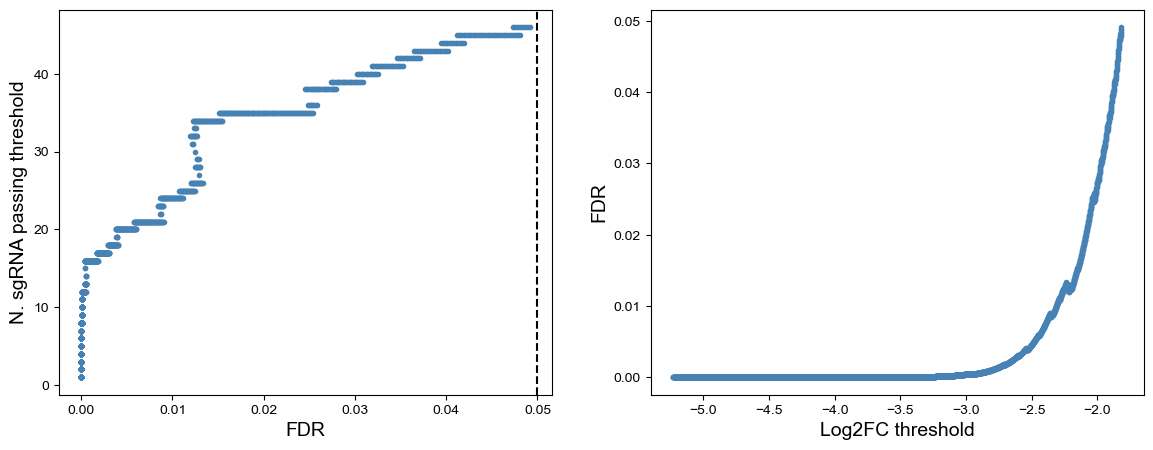

In [156]:
target_col = 'log2fc_ARB_CASP_median'

bins = np.linspace(min(screen_clin_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(14,5))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


for val in bins:

    FPR = stats.norm.cdf(val, loc=ARB_CASP_on_mean, scale=ARB_CASP_on_scale)

    positives = len([x for x in screen_clin_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_clin_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)

    if FDR >= 0.0099:
        print(val, FPR, positives, PR, FDR) 

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axvline(0.05, color='k', linestyle='--')
ax1.set_xlabel('FDR', fontsize=14)
ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)


ax2.set_xlabel('Log2FC threshold', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)

In [157]:
threshold_ARB_CASP_on = -1.817789390153988

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

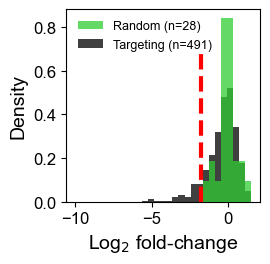

In [158]:
plt.figure(figsize=(2.5,2.5))

plt.hist(screen_clin_counts[is_control]['log2fc_ARB_CASP_median'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.hist(screen_clin_counts[is_test]['log2fc_ARB_CASP_median'], color='k', alpha=0.75, bins = np.linspace(-10,1.5,30), density=True)
plt.legend(['Random (n=28)', 'Targeting (n=491)'], fontsize=9, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(threshold_ARB_CASP_on, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



In [159]:
for col in ['log2fc_ARB_1', 'log2fc_ARB_2', 'log2fc_ARB_3', 'log2fc_ARB_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-wt_on_mean)/wt_on_scale

for col in ['log2fc_ARB_CASP_1', 'log2fc_ARB_CASP_2', 'log2fc_ARB_CASP_3', 'log2fc_ARB_CASP_median']:
    screen_clin_counts[(col+'_z_score')] = (screen_clin_counts[col]-ARB_CASP_on_mean)/ARB_CASP_on_scale

In [160]:
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,ERB_CASP_effect_p_value,ERB_CASP_effect_p_value_corr,log2fc_ARB_1_z_score,log2fc_ARB_2_z_score,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.413360,0.604994,-0.305649,1.349468,0.599188,0.599188,-1.792431,1.692502,2.062074,1.692502
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.318151,0.526937,0.122539,0.297179,0.367617,0.297179,0.087253,-0.193011,0.616168,0.087253
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,0.337424,0.549369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,0.955677,0.984202,-0.725174,0.113555,-0.381088,-0.381088,1.339284,1.577604,-0.017196,1.339284
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.010487,0.095855,0.597246,0.396927,-0.430974,0.396927,0.519852,-3.248244,-2.905514,-2.905514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.054377,0.208311,0.198145,0.091144,0.220691,0.198145,0.087023,-0.128105,0.271168,0.087023
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.026978,0.154454,0.424841,0.398949,0.182946,0.398949,0.826301,0.136426,0.551072,0.551072
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.033041,0.166698,-0.331529,-0.145128,-0.064270,-0.145128,-0.664703,-0.705353,-1.110723,-0.705353
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.129581,0.332571,-1.079389,-0.768030,-0.570697,-0.768030,-2.339026,-1.549343,-0.432420,-1.549343


In [161]:
screen_clin_counts[['log2fc_ARB_1_z_score', 'log2fc_ARB_2_z_score', 'log2fc_ARB_3_z_score',
                 'log2fc_ARB_CASP_1_z_score', 'log2fc_ARB_CASP_2_z_score', 'log2fc_ARB_CASP_3_z_score' ]]

,log2fc_ARB_1_z_score,log2fc_ARB_2_z_score,log2fc_ARB_3_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score
0,-0.305649,1.349468,0.599188,-1.792431,1.692502,2.062074
1,0.122539,0.297179,0.367617,0.087253,-0.193011,0.616168
2,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.725174,0.113555,-0.381088,1.339284,1.577604,-0.017196
4,0.597246,0.396927,-0.430974,0.519852,-3.248244,-2.905514
...,...,...,...,...,...,...
548,0.198145,0.091144,0.220691,0.087023,-0.128105,0.271168
549,0.424841,0.398949,0.182946,0.826301,0.136426,0.551072
550,-0.331529,-0.145128,-0.064270,-0.664703,-0.705353,-1.110723
551,-1.079389,-0.768030,-0.570697,-2.339026,-1.549343,-0.432420


In [162]:
screen_clin_counts['log2fc_ARB_CASP_effect'] = screen_clin_counts['log2fc_ARB_CASP_median_z_score'] - screen_clin_counts['log2fc_ARB_median_z_score']

In [163]:
YPD_cols = ['log2fc_ARB_1_z_score', 'log2fc_ARB_2_z_score', 'log2fc_ARB_3_z_score']
CASP_cols = ['log2fc_ARB_CASP_1_z_score', 'log2fc_ARB_CASP_2_z_score', 'log2fc_ARB_CASP_3_z_score']

def ttest_row(row):
    return stats.ttest_ind(row[YPD_cols].astype(np.float64), row[CASP_cols].astype(np.float64), equal_var=False)

In [164]:
results_ARB_CASP_effect = screen_clin_counts.apply(ttest_row, axis=1)
screen_clin_counts['ARB_CASP_effect_t_stat'] = [r.statistic for r in results_ARB_CASP_effect]
screen_clin_counts['ARB_CASP_effect_p_value'] = [r.pvalue for r in results_ARB_CASP_effect]

ARB_CASP_p_value_corr = stats.false_discovery_control(screen_clin_counts['ARB_CASP_effect_p_value'].dropna(), method='bh')

# convert to np.log10 and apply Bonferonni

In [165]:
corr_pval_index_ARB_CASP = list((screen_clin_counts['ARB_CASP_effect_p_value'].dropna().index))

corr_pval_col_dict = {}
for x in range(0, len(corr_pval_index_ARB_CASP)):
    corr_pval_col_dict[corr_pval_index_ARB_CASP[x]] = ARB_CASP_p_value_corr[x]


screen_clin_counts['ARB_CASP_effect_p_value_corr'] = pd.Series(corr_pval_col_dict)
screen_clin_counts

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.599188,0.599188,-1.792431,1.692502,2.062074,1.692502,1.093314,-0.080724,0.941477,0.956274
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.367617,0.297179,0.087253,-0.193011,0.616168,0.087253,-0.209926,0.371955,0.740564,0.821613
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.381088,-0.381088,1.339284,1.577604,-0.017196,1.339284,1.720372,-2.345765,0.103438,0.238734
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.430974,0.396927,0.519852,-3.248244,-2.905514,-2.905514,-3.302440,1.661239,0.223465,0.371484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.220691,0.198145,0.087023,-0.128105,0.271168,0.087023,-0.111121,0.764112,0.511021,0.630521
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.182946,0.398949,0.826301,0.136426,0.551072,0.551072,0.152123,-0.787374,0.497118,0.620798
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,-0.064270,-0.145128,-0.664703,-0.705353,-1.110723,-0.705353,-0.560225,3.969553,0.026448,0.118900
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,-0.570697,-0.768030,-2.339026,-1.549343,-0.432420,-1.549343,-0.781313,1.107693,0.370870,0.508594


In [166]:
screen_clin_counts[['ARB_CASP_effect_p_value']]

,ARB_CASP_effect_p_value
0,0.941477
1,0.740564
2,NaN
3,0.103438
4,0.223465
...,...
548,0.511021
549,0.497118
550,0.026448
551,0.370870


(-8.0, 8.0)

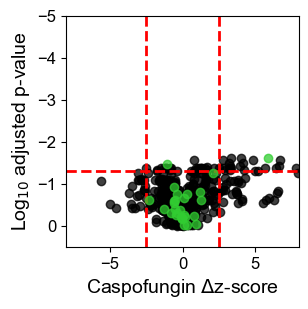

In [167]:
plt.figure(figsize=(3,3))

plt.scatter(screen_clin_counts[is_control]['log2fc_ARB_CASP_effect'], np.log10(screen_clin_counts[is_control]['ARB_CASP_effect_p_value_corr']), color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_clin_counts[is_test]['log2fc_ARB_CASP_effect'], np.log10(screen_clin_counts[is_test]['ARB_CASP_effect_p_value_corr']), color='k', alpha=0.75)


plt.ylim(0.5,-5)

plt.axhline(np.log10(0.05), linestyle='--', color='red', lw=2)
plt.axvline(-2.489, linestyle='--', color='red', lw=2)
plt.axvline(2.489, linestyle='--', color='red', lw=2)

plt.xlabel(r'Caspofungin $\Delta$z-score', fontsize=14)
plt.xticks(fontsize=12)

plt.ylabel('Log$_{10}$ adjusted p-value', fontsize=14)
plt.yticks(fontsize=12)

plt.xlim(-8,8)



In [168]:
(threshold_ARB_on-ARB_CASP_on_mean)/ARB_on_scale

-2.377099709065295

In [169]:
(threshold_ARB_CASP_on-ARB_CASP_on_mean)/ARB_CASP_on_scale

-2.6015304528956635

In [170]:
np.mean([(threshold_ARB_on-ARB_CASP_on_mean)/ARB_on_scale, (threshold_ARB_CASP_on-ARB_CASP_on_mean)/ARB_CASP_on_scale])

-2.4893150809804796

In [171]:
screen_clin_counts[(screen_clin_counts['log2fc_ARB_CASP_effect']<-2.489)&(screen_clin_counts['ARB_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA',                                                                                                                                                                                   'log2fc_ARB_median_z_score', 'log2fc_ARB_CASP_median_z_score', 'log2fc_ARB_CASP_effect', 'ARB_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_ARB_median_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_p_value_corr
123,C1_12260W,VPH2,124,0.488745,-2.034945,-2.523689,0.042119


In [172]:
screen_clin_counts[(screen_clin_counts['log2fc_ARB_CASP_effect']>2.489)&(screen_clin_counts['ARB_CASP_effect_p_value_corr']<0.05)][['Gene', 'alias', 'SgRNA', 'log2fc_ARB_median_z_score', 'log2fc_ARB_CASP_median_z_score', 'log2fc_ARB_CASP_effect' , 'ARB_CASP_effect_p_value_corr']]

,Gene,alias,SgRNA,log2fc_ARB_median_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_p_value_corr
60,C1_05500W,RSM22,61,-2.255180,0.994282,3.249461,0.037742
61,C1_05500W,RSM22,62,-7.752282,-2.043485,5.708796,0.042119
103,C1_09450C,NUP188,104,-5.213920,-1.915312,3.298608,0.047849
131,C1_12610W,C1_12610W,132,-8.148439,-1.439674,6.708765,0.027974
165,C2_03560C,C2_03560C,166,-2.675754,0.674764,3.350518,0.042174
171,C2_04590C,QCR8,172,-4.422063,-1.238886,3.183177,0.043001
190,C2_06290C,ATP14,193,-11.136761,-3.354672,7.782089,0.042119
192,C2_06290C,ATP14,195,-2.212055,1.119296,3.331351,0.024329
219,C3_01080W,MRPL33,222,-10.049323,-1.682442,8.366881,0.042174
263,C4_00560C,MMM1,266,-4.553507,0.262621,4.816128,0.027974


In [173]:
w_significant_changes_ARB = (screen_clin_counts['ARB_CASP_effect_p_value_corr']<=0.05)

w_antagonism_ARB = screen_clin_counts['log2fc_ARB_CASP_effect'] >=2.489
w_synergy_ARB = screen_clin_counts['log2fc_ARB_CASP_effect'] <=-2.489

In [174]:
significant_antagonism_both=core_essential_target&w_significant_changes_WT&w_antagonism_WT&w_significant_changes_ARB&w_antagonism_ARB
screen_clin_counts[significant_antagonism_both]
# one sgRNA with significant antagonism in both strains

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr
165,C2_03560C,C2_03560C,166,AGGAAATTCGCCAGAACTCT,0,+,105.0,no,-79.0,79.0,...,-2.675754,-2.675754,0.674764,1.503183,0.558574,0.674764,3.350518,-11.407222,0.002166,0.042174


In [175]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_synergy_WT&w_significant_changes_ARB&w_synergy_ARB]
# No significant synergy in both strains

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr


In [176]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_antagonism_WT&w_significant_changes_ARB&w_synergy_ARB]
# No sign epistasis -/+

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr


In [177]:
screen_clin_counts[core_essential_target&w_significant_changes_WT&w_synergy_WT&w_significant_changes_ARB&w_antagonism_ARB]
# No sign epistasis +/-

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr


In [178]:
significant_synergy_WT = core_essential_target&w_significant_changes_WT&w_synergy_WT
screen_clin_counts[significant_synergy_WT]
# synergy, WT only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr
169,C2_04590C,QCR8,170,TCTCTCTCTCACTTTGGTGG,0,-,109.0,no,-78.0,78.0,...,-1.419233,-1.56271,-3.331068,-5.4123,-4.18929,-4.18929,-2.62658,4.041949,0.037215,0.140914


In [179]:
screen_clin_counts[core_essential_target&w_significant_changes_ARB&w_synergy_ARB]
# synergy, ARB only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr


In [180]:
significant_antagonism_WT = core_essential_target&w_significant_changes_WT&w_antagonism_WT&~significant_antagonism_both
screen_clin_counts[significant_antagonism_WT]
# antagonism, WT only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr
214,C2_10280C,SPT23,217,AAAGTGGAAAGTGGTGGAGG,0,-,150.0,no,11.0,11.0,...,0.120651,0.114361,1.477901,1.827465,0.085752,1.477901,1.363540,-2.035061,0.172898,0.316201
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,0,+,247.0,no,-171.0,171.0,...,-7.681589,-7.168171,-3.334167,-6.597372,-2.151382,-3.334167,3.834005,-2.094304,0.145628,0.288466


In [181]:
significant_antagonism_ARB = core_essential_target&w_significant_changes_ARB&w_antagonism_ARB&~significant_antagonism_both
screen_clin_counts[significant_antagonism_ARB]
# antagonism, ARB only

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ARB_3_z_score,log2fc_ARB_median_z_score,log2fc_ARB_CASP_1_z_score,log2fc_ARB_CASP_2_z_score,log2fc_ARB_CASP_3_z_score,log2fc_ARB_CASP_median_z_score,log2fc_ARB_CASP_effect,ARB_CASP_effect_t_stat,ARB_CASP_effect_p_value,ARB_CASP_effect_p_value_corr
60,C1_05500W,RSM22,61,TAAGACACAAAAGTGGAAAC,0,+,94.0,no,NaN,NaN,...,-2.320334,-2.255180,1.385071,0.994282,0.668235,0.994282,3.249461,-13.818595,0.000907,0.037742
61,C1_05500W,RSM22,62,ACACAAAAGTGGAAACAGGA,0,+,90.0,no,NaN,NaN,...,-7.457589,-7.752282,-2.029578,-2.043485,-2.929795,-2.043485,5.708796,-9.604687,0.001899,0.042119
103,C1_09450C,NUP188,104,TCTTTGATGGTTTAACTTCC,0,-,242.0,no,-172.0,172.0,...,-5.543917,-5.213920,-1.915312,-0.841326,-2.131078,-1.915312,3.298608,-7.785984,0.003820,0.047849
171,C2_04590C,QCR8,172,TCTCTCTCTCTCTCTCACTT,0,-,103.0,no,-72.0,72.0,...,-4.613992,-4.422063,-1.238886,-0.856753,-1.694965,-1.238886,3.183177,-12.504017,0.002828,0.043001
219,C3_01080W,MRPL33,222,CAACGTTAAGGAAGGAAGGA,0,+,95.0,no,-19.0,19.0,...,-8.932382,-10.049323,-1.682442,-2.273500,-1.064725,-1.682442,8.366881,-10.459796,0.002272,0.042174
263,C4_00560C,MMM1,266,AGTGCCAGAGATTTCACAGT,0,+,88.0,no,-53.0,53.0,...,-4.465569,-4.553507,0.691867,0.262621,-0.227756,0.262621,4.816128,-15.716116,0.000300,0.027974
264,C4_00560C,MMM1,267,TGCCAGAGATTTCACAGTGG,0,+,86.0,no,-51.0,51.0,...,-7.564221,-8.722077,-2.011090,-2.843831,-2.068063,-2.068063,6.654014,-11.744328,0.000869,0.037742
273,C4_01150W,ASK1,276,TTAGTGGTGGTAAGTGGAGG,0,+,192.0,no,-164.0,164.0,...,-5.701954,-6.276409,-2.051733,-0.949470,-2.445567,-2.051733,4.224676,-6.372976,0.003982,0.047849


In [182]:
screen_clin_counts.at[273, 'log2fc_WT_CASP_effect']

nan

In [183]:
all_significant_genes = screen_clin_counts[significant_synergy_WT|significant_antagonism_WT|significant_antagonism_ARB|significant_antagonism_both]['alias'].unique()
all_significant_genes

array(['RSM22', 'NUP188', 'C2_03560C', 'QCR8', 'SPT23', 'MRPL33', 'MMM1',
       'ASK1'], dtype=object)

In [184]:
color_list = sns.color_palette('hls',len([x for x in all_significant_genes if x !='ASK1']))

In [185]:
color_dict = {}
for x in range(0,len([x for x in all_significant_genes if x !='ASK1'])):
    color_dict[all_significant_genes[x]] = color_list[x]

for x in background_condition_hits:
    if x not in list(color_dict.keys()):
        color_dict[x] = 'k'

color_dict

{'RSM22': (0.86, 0.3712, 0.33999999999999997),
 'NUP188': (0.86, 0.8169142857142857, 0.33999999999999997),
 'C2_03560C': (0.4573714285714283, 0.86, 0.33999999999999997),
 'QCR8': (0.33999999999999997, 0.86, 0.6683428571428571),
 'SPT23': (0.33999999999999997, 0.6059428571428571, 0.86),
 'MRPL33': (0.5197714285714281, 0.33999999999999997, 0.86),
 'MMM1': (0.86, 0.33999999999999997, 0.7545142857142858),
 'ASK1': 'k',
 'ATP17': 'k',
 'ATP4': 'k',
 'C1_08920W': 'k',
 'C2_07680W': 'k',
 'FOL1': 'k',
 'ILV3': 'k',
 'ILV5': 'k',
 'MET6': 'k',
 'RTT109': 'k'}

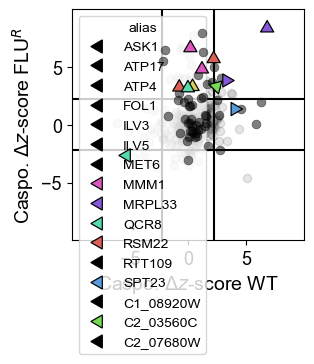

In [186]:
plt.figure(figsize=(3,3))


sns.scatterplot(data=screen_clin_counts[core_essential_target&~significant_synergy_WT&~significant_antagonism_WT&~significant_antagonism_ARB], x='log2fc_WT_CASP_effect', y='log2fc_ARB_CASP_effect', 
                     zorder=6, s=40, color='k', edgecolor='k', marker='o', legend=False, alpha=0.5)




sns.scatterplot(data=screen_clin_counts[core_essential_target&significant_antagonism_both], 
                     x='log2fc_WT_CASP_effect', y='log2fc_ARB_CASP_effect', 
                     hue='alias',zorder=9, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 315), legend=False, palette=color_dict)

sns.scatterplot(data=screen_clin_counts[core_essential_target&significant_antagonism_WT], x='log2fc_WT_CASP_effect', y='log2fc_ARB_CASP_effect', 
                     hue='alias',zorder=8, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 270), legend=False, palette=color_dict)

sns.scatterplot(data=screen_clin_counts[significant_antagonism_ARB], x='log2fc_WT_CASP_effect', y='log2fc_ARB_CASP_effect', 
                     hue='alias',zorder=7, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 0), legend=False, palette=color_dict)

ax = sns.scatterplot(data=screen_clin_counts[core_essential_target&significant_synergy_WT], 
                     x='log2fc_WT_CASP_effect', y='log2fc_ARB_CASP_effect', 
                     hue='alias',zorder=9, s=120, hue_order=gene_order, edgecolor='k', marker=(3, 0, 90), legend=True, palette=color_dict)

plt.scatter(screen_clin_counts[~core_essential_target&is_test]['log2fc_WT_CASP_effect'], screen_clin_counts[~core_essential_target&is_test]['log2fc_ARB_CASP_effect'], color='k', alpha=0.1,zorder=5)

#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncols=2, fontsize=11, markerscale=1.75, handletextpad=0.05, frameon=False)


plt.axvline(-2.27, color='k')
plt.axvline(2.27, color='k')

plt.axhline(-2.20, color='k')
plt.axhline(2.20, color='k')

plt.xlim(-10,10)
plt.xticks([-5,0,5], fontsize=13)
plt.ylim(-10,10)
plt.yticks([-5,0,5], fontsize=13)

plt.xlabel(r'Caspo. $\it{\Delta}z$-score WT', fontsize=14)
plt.ylabel(r'Caspo. $\it{\Delta}z$-score FLU$^{R}$', fontsize=14)

plt.savefig('./figures/casp_effect_core_essential_genes_FLUr.svg', format='svg', dpi=300)

## Compare with multi-environment screens

In [187]:
all_condition_hit_list = ['C1_03280W', 'RSM22', 'MRPL3', 'C1_08920W', 'NUP188',
                          'C2_03560C', 'QCR8', 'ATP4', 'C2_07680W', 'RRP15',
                          'SPT23', 'MRPL33', 'C3_05800W', 'C3_06520C', 'MMM1',
                          'ASK1', 'FOL1', 'ILV3', 'ILV5', 'ATP17', 'RTT109', 'MET6']

In [188]:
background_condition_hits = sorted([x for x in all_background_hits if x in all_condition_hit_list]), len([x for x in all_background_hits if x in all_condition_hit_list])

In [189]:
for y in sorted([x for x in all_background_hits if x in all_condition_hit_list]):
    print(y)

ASK1
ATP17
ATP4
C1_08920W
C2_03560C
C2_07680W
FOL1
ILV3
ILV5
MET6
MMM1
MRPL33
NUP188
QCR8
RSM22
RTT109
SPT23


In [190]:
screen_clin_counts.to_csv('./Table_S8.csv', sep=',')